In [1]:
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import sys
sys.path.append('.')

from utils import *
from experiment import *
from dataloader.vlfc import COMPANIES
from visualize import *

# Quick start with a single experiment

We start with runing a single time series forecasting experiment. We will run return forecasting problem on AMD stock return with baseline adapative conformal inference (ACI) methods.

### Load the hyper parameters of the model

The first step is to load the config file in `bellman-conformal-inference/config`.

In [2]:
params = read_yaml('config/rtfc-aci-AMD.yaml')

The naming of the config file follows the convention of `TASK_NAME-METHOD_NAME-TASK_DATASET.yaml`. In this case, the config file looks like

```
> params

{'task': 'rtfc',        # the return forecasting problem, avalibale choices ['rtfc', 'vlfc']
 'method': 'aci',       # the adapative conformal algorithm to use. 'aci' means baseline Adapative Conformal Algorithm
 'id': 'AMD',           # the dataset to be used by the experiment. They can be found in 'data/'
 'alpha0': 0.1,         # target miscoverage rate. In this case 10%
 'gamma': 0.1,          # step size for either ACI or BCI
 'lambda_init': 0.9,
 'lambda_max': 1.0,
 'lambda_min': 0.0}
```

We can run the experiment by using the `.run()` method, which captures all the details of computing $\alpha_t$ for each $t$. To hack around the code, please see `experiment.py` for the logic of computing $\alpha_t$.

### Build the experiment object and run the experiment

The experiment object created by

In [3]:
exp = ForecastingExperiment(params)

In [4]:
exp.run()

2026-03-02 11:56:26,257 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED


2026-03-02 11:56:28,674 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 2.4171392917633057s


After we run the experiment, we can optionally save the experiment. They will be saved in `bellman-conformal-inference/result/*`. This include the full trajectory of the experiment, and the hyper parameter used.

In [5]:
exp.save()

Finally, we can visualize the experiment by calling the `visualize_single_exp(**)` function defined in `bellman-conformal-inference/visualize.py`.

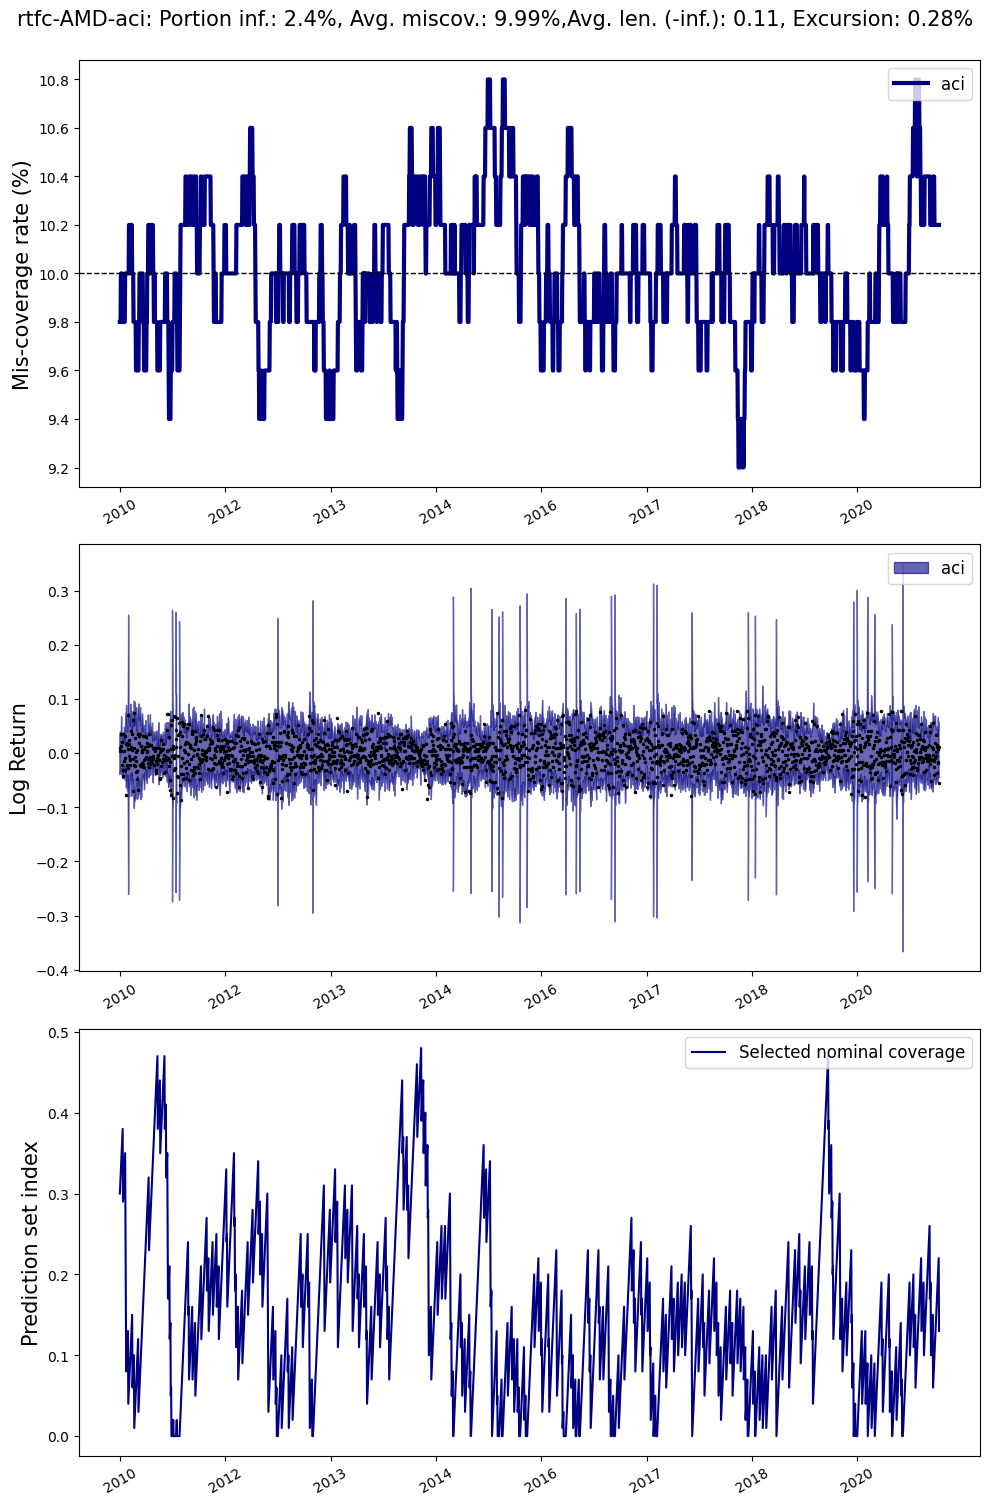

In [6]:
visualize_single_exp(exp.params, exp.result)

# Comparsion of three experiments

Next we demonstrate how to compare performance across three methods -- ACI, BCI, fixed $\alpha_t$ for the same experiment.

In [7]:
exp_aci = ForecastingExperiment(read_yaml('config/rtfc-aci-AMD.yaml'))
exp_aci.run()

exp_bci = ForecastingExperiment(read_yaml('config/rtfc-bci-AMD.yaml'))
exp_bci.run()

exp_fixed = ForecastingExperiment(read_yaml('config/rtfc-fixed-AMD.yaml'))
exp_fixed.run()

2026-03-02 11:56:34,027 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED
2026-03-02 11:56:36,575 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 2.5486810207366943s
2026-03-02 11:56:36,583 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 STARTED
2026-03-02 11:56:45,131 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 ENDED in 8.54807996749878s
2026-03-02 11:56:45,139 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA STARTED
2026-03-02 11:56:47,365 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA ENDED in 2.2262301445007324s


As before, we can visualize the comparsion as `visualize_three_exp`. In contrast to the previous plot, the figure first panel is the moving average mis-coverage rate, and the bottom panel is the moving average of interval length. The performance metric is given in the title of the plot:

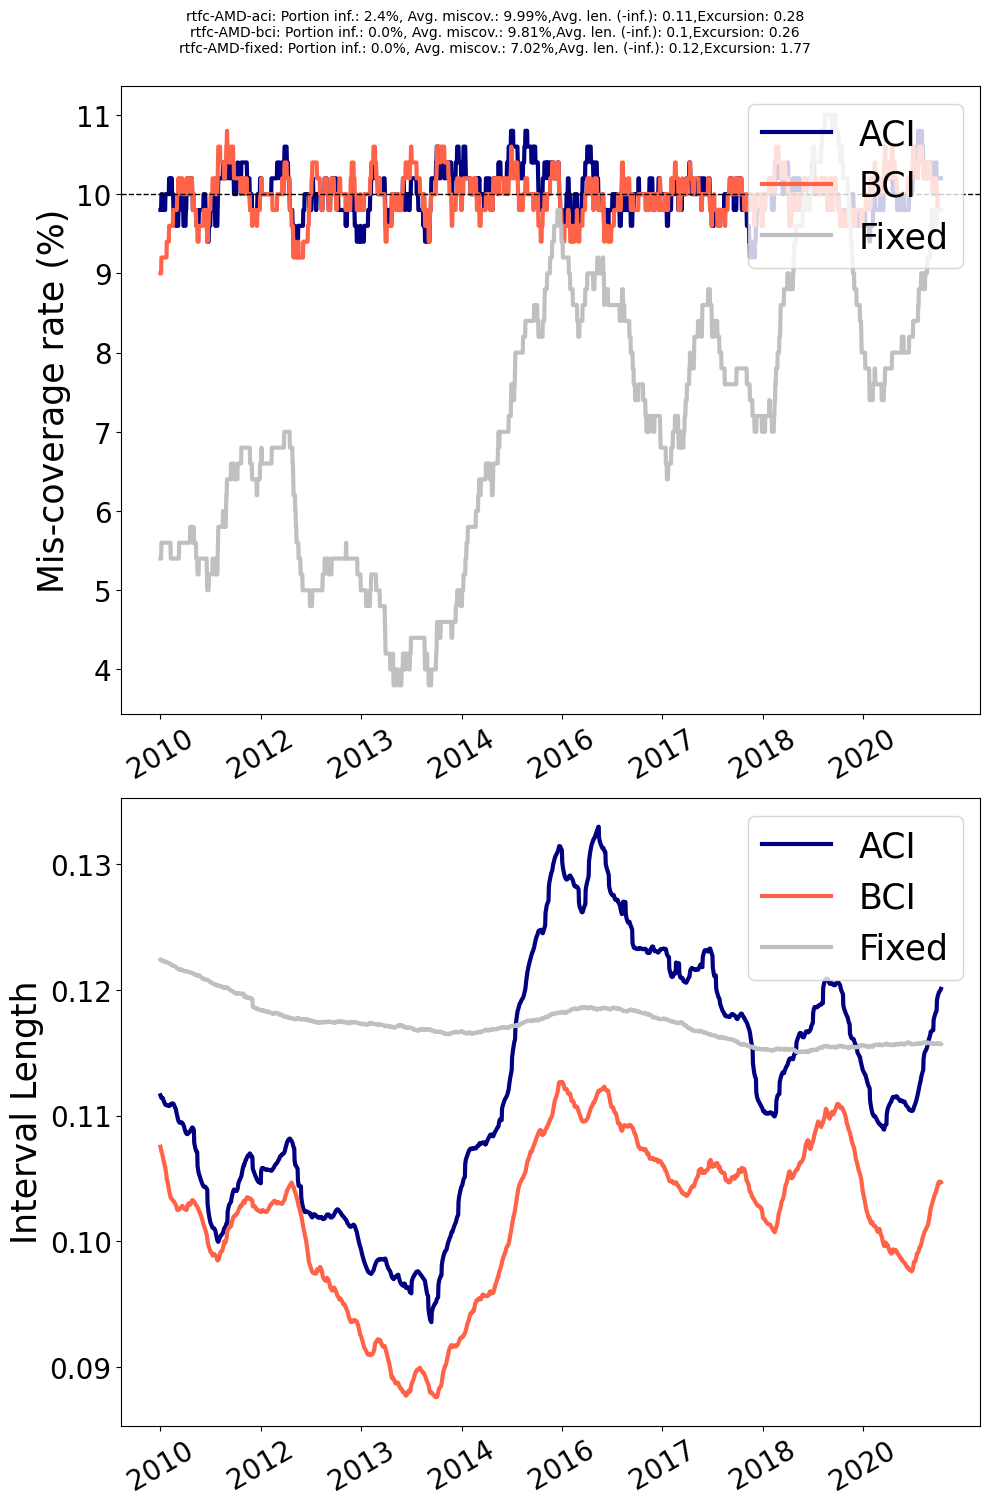

In [8]:
visualize_three_exp(exp_aci.params, exp_aci.result,
                    exp_bci.params, exp_bci.result,
                    exp_fixed.params, exp_fixed.result)

In [6]:
"""
QUICK TEST: Static argmin lambda_max via PLATEAU DETECTION
        on Google Trends, ACI gamma=0.1

Stage 1: STATIC argmin (no BCI run, no gamma).
  For each lambda in geometric grid:
    beta(lambda) = argmin_beta [ avg_t |C_t(1-beta)| + lambda*(avg_t I(error) - alpha_bar) ]
  Find lambda_max = the smallest lambda at which beta(lambda) has plateaued
  (i.e., reached its asymptotic value as lambda -> inf).

Stage 2: For each multiplier in MULTIPLIERS: tune c per T to match ACI's rolling std.

NOTES on Trends-specific differences from VLFC:
- Uses TrendData (normal-dist forecaster, 7-step horizon) instead of VolatilityData.
- Lengths are computed in RAW space (no sqrt), unlike VLFC which uses sqrt-space.
"""

import numpy as np
import pandas as pd
import sys
import logging

from utils import read_yaml
from experiment import ForecastingExperiment
from dataloader.trendfc import TrendData

logging.getLogger().setLevel(logging.WARNING)
sys.setrecursionlimit(10000)

ALPHA_BAR  = 0.1
BURNIN     = 100
SEARCH_END = 100
EVAL_ROLL  = 50

C_GRID_SIZE = 40
C_GRID      = np.geomspace(1e-3, 1e4, C_GRID_SIZE)

# Granular grid per advisor's suggestion (1000 points)
LAMBDA_GRID_WB = np.geomspace(1e-4, 1e6, 1000)
BETA_GRID_WB   = np.geomspace(1e-7, 0.99, 200)

# Tolerance for "plateau reached"
PLATEAU_TOL = 1.01

MULTIPLIERS = [100.0]
T_VALS      = [2, 3, 5, 7]

DATASET     = 'google_trends'
ACI_GAMMA   = 0.008
TASK        = 'trend'

# =============================================================================
# STATIC ARGMIN LAMBDA_MAX VIA PLATEAU DETECTION
# =============================================================================
def find_lambda_max_plateau(fcdata, alpha_bar=ALPHA_BAR, plateau_tol=PLATEAU_TOL,
                            verbose=True):
    fcdata.refresh()
    lengths = np.zeros((SEARCH_END, len(BETA_GRID_WB)))
    beta_ts = np.zeros(SEARCH_END)
    for i in range(SEARCH_END):
        data = fcdata.next()
        if data is False:
            lengths = lengths[:i]; beta_ts = beta_ts[:i]; break
        nps0 = data['nested_pred_sets'][0]
        lengths[i, :] = nps0.upper.eval(BETA_GRID_WB) - nps0.lower.eval(BETA_GRID_WB)
        beta_ts[i]    = float(data['beta'])
    fcdata.refresh()

    avg_length     = lengths.mean(axis=0)
    miscov_at_beta = (BETA_GRID_WB[None, :] > beta_ts[:, None]).mean(axis=0)

    beta_of_lambda = np.zeros(len(LAMBDA_GRID_WB))
    miscov_at_opt  = np.zeros(len(LAMBDA_GRID_WB))
    for k, lam in enumerate(LAMBDA_GRID_WB):
        loss   = avg_length + lam * np.maximum(miscov_at_beta - alpha_bar, 0)
        j_star = int(np.argmin(loss))
        beta_of_lambda[k] = BETA_GRID_WB[j_star]
        miscov_at_opt[k]  = miscov_at_beta[j_star]

    plateau_value = beta_of_lambda[-1]
    threshold     = plateau_value * plateau_tol

    lambda_max  = None
    plateau_idx = None
    for k in range(len(LAMBDA_GRID_WB)):
        if beta_of_lambda[k] <= threshold:
            lambda_max  = LAMBDA_GRID_WB[k]
            plateau_idx = k
            break

    if lambda_max is None:
        lambda_max  = LAMBDA_GRID_WB[-1]
        plateau_idx = len(LAMBDA_GRID_WB) - 1

    if verbose:
        print(f"\n  Plateau detection:")
        print(f"    plateau_value = {plateau_value:.6e}")
        print(f"    threshold = {threshold:.6e}")
        print(f"    First lambda at plateau: lambda[{plateau_idx}] = {lambda_max:.4e}")
        print(f"    beta(lambda_max) = {beta_of_lambda[plateau_idx]:.6e}\n")

        start = max(0, plateau_idx - 5)
        end   = min(len(LAMBDA_GRID_WB), plateau_idx + 5)
        print(f"  Trace around plateau onset:")
        print(f"  {'lambda':>14} {'beta(lambda)':>14} {'miscov@beta*':>14}  {'note':<14}")
        print(f"  {'-'*64}")
        for k in range(start, end):
            note = "<-- plateau onset" if k == plateau_idx else ""
            print(f"  {LAMBDA_GRID_WB[k]:>14.4e} {beta_of_lambda[k]:>14.6f} "
                  f"{miscov_at_opt[k]:>14.4f}  {note:<14}")
        print()

        print(f"  ** lambda_max (raw, at plateau onset) = {lambda_max:.4e} **")
        print(f"  ** lambda_init = 0.01 * lambda_max     = {0.01 * lambda_max:.4e} **\n")

    return float(lambda_max)


# =============================================================================
# METRICS / RUNNERS
# =============================================================================
def _err_ind(df):
    a = pd.to_numeric(df['alpha'], errors='coerce')
    b = pd.to_numeric(df['beta'],  errors='coerce')
    return (a > b).astype(float)


def compute_full_miscov_std(result_df):
    df = result_df.iloc[BURNIN:].copy()
    return float(_err_ind(df).rolling(window=EVAL_ROLL, min_periods=1).mean().std())


def compute_metrics(result_df):
    """Days 100+. Lengths in RAW space (Trends doesn't use sqrt)."""
    df    = result_df.iloc[BURNIN:].copy()
    ei    = _err_ind(df)
    upper = pd.to_numeric(df['upper'], errors='coerce')
    lower = pd.to_numeric(df['lower'], errors='coerce')

    rolling_std = ei.rolling(window=EVAL_ROLL, min_periods=1).mean().std()
    raw_lengths = upper - lower
    valid       = raw_lengths[np.isfinite(raw_lengths)]
    frac_inf    = (~np.isfinite(raw_lengths)).mean()

    return {
        'miscov':      float(ei.mean()),
        'rolling_std': float(rolling_std),
        'length':      float(valid.mean()) if len(valid) > 0 else float('nan'),
        'frac_inf':    float(frac_inf),
    }


def run_bci(bci_cfg_raw, lambda_max, c, T):
    cfg = dict(bci_cfg_raw)
    cfg['lambda_max']  = float(lambda_max)
    cfg['lambda_init'] = float(0.01 * lambda_max)
    cfg['gamma']       = float(c * lambda_max)
    cfg['T']           = int(T)
    exp = ForecastingExperiment(cfg)
    exp.run()
    return exp.result


def tune_c(bci_cfg_raw, lambda_max, target_std, T):
    best_c, best_diff = C_GRID[0], np.inf
    for c in C_GRID:
        res  = run_bci(bci_cfg_raw, lambda_max, c, T)
        diff = abs(compute_full_miscov_std(res) - target_std)
        if diff < best_diff:
            best_diff, best_c = diff, c
    return best_c

import matplotlib.pyplot as plt

def diagnostic_sweep_plot(bci_cfg_raw, lambda_max, T, target_std):
    c_values = np.geomspace(1e-7, 1, 20) # Focusing on the lower range
    stds = []
    miscovs = []

    print(f"Starting diagnostic sweep for T={T}...")
    for c in c_values:
        res = run_bci(bci_cfg_raw, lambda_max, c, T)
        metrics = compute_metrics(res)
        stds.append(metrics['rolling_std'])
        miscovs.append(metrics['miscov'])

    # Create the plot
    fig, ax1 = plt.subplots(figsize=(10, 6))

    color = 'tab:blue'
    ax1.set_xlabel('c (Learning Rate Multiplier)')
    ax1.set_ylabel('Rolling Std (Stability)', color=color)
    ax1.plot(c_values, stds, marker='o', color=color, label='Rolling Std')
    ax1.axhline(y=target_std, color='r', linestyle='--', label='ACI Target Std')
    ax1.set_xscale('log')
    ax1.tick_params(axis=y, labelcolor=color)

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Miscoverge (Accuracy)', color=color)
    ax2.plot(c_values, miscovs, marker='x', color=color, label='Miscoverage')
    ax2.axhline(y=0.1, color='black', linestyle=':', label='Target 0.1')
    ax2.tick_params(axis=y, labelcolor=color)

    plt.title(f'Google Trends Diagnostic: T={T}, $\lambda_{{max}}$={lambda_max:.2e}')
    fig.tight_layout()
    plt.savefig(f'diagnostic_plot_T{T}.png')
    plt.show()

# Run this inside your __main__ block
# =============================================================================
# MAIN
# =============================================================================
if __name__ == "__main__":
    print(f"\n{'='*80}")
    print(f"### {TASK.upper()} | {DATASET} | ACI gamma = {ACI_GAMMA}")
    print(f"{'='*80}")

    aci_cfg     = read_yaml(f'config/{TASK}-aci.yaml')
    bci_cfg_raw = read_yaml(f'config/{TASK}-bci.yaml')

    # YAML wraps values in single-element lists; flatten to scalars.
    def flatten(cfg):
        for k, v in list(cfg.items()):
            if isinstance(v, list) and len(v) == 1:
                cfg[k] = v[0]
        return cfg
    aci_cfg     = flatten(aci_cfg)
    bci_cfg_raw = flatten(bci_cfg_raw)

    aci_cfg['gamma'] = ACI_GAMMA
    for k in ['lambda_max', 'lambda_init', 'gamma']:
        bci_cfg_raw.pop(k, None)

    print("Running ACI (target for tuning)...")
    exp_aci = ForecastingExperiment(aci_cfg)
    exp_aci.run()
    m_aci   = compute_metrics(exp_aci.result)
    aci_std = m_aci['rolling_std']
    print(f"  ACI: miscov={m_aci['miscov']*100:.2f}%  len={m_aci['length']:.4f}  "
          f"std={aci_std:.4f}  frac_inf={m_aci['frac_inf']*100:.2f}%")

    print("\nStage 1: static argmin lambda_max via plateau detection...")
    lambda_max_raw = find_lambda_max_plateau(TrendData(DATASET), verbose=True)

    rows = [{'mult': '-', 'lmax': '-', 'T': '-', 'c': '-', 'method': 'ACI', **m_aci}]

    for mult in MULTIPLIERS:
        lmax = mult * lambda_max_raw
        print(f"--- multiplier = {mult}x  ->  lambda_max = {lmax:.2f}, "
              f"lambda_init = {0.01*lmax:.2f} ---")

        for T in T_VALS:
            print(f"  T={T}  tuning c ({C_GRID_SIZE} candidates)...")
            c_best = tune_c(bci_cfg_raw, lmax, aci_std, T)
            res    = run_bci(bci_cfg_raw, lmax, c_best, T)
            m      = compute_metrics(res)
            rows.append({'mult': f'{mult:.0f}x', 'lmax': f'{lmax:.2e}',
                         'T': T, 'c': f'{c_best:.4e}',
                         'method': f'BCI(T={T})', **m})
            print(f"    c={c_best:.4e}  miscov={m['miscov']*100:.2f}%  "
                  f"len={m['length']:.4f}  std={m['rolling_std']:.4f}  "
                  f"frac_inf={m['frac_inf']*100:.2f}%")
        print()

    print(f"\n{'='*100}")
    print(f"SUMMARY — {DATASET} γ={ACI_GAMMA}, ACI rolling std target = {aci_std:.4f}")
    print(f"Static lambda_max (plateau onset) = {lambda_max_raw:.4e}")
    print(f"{'='*100}")
    print(f"{'Mult':<6} {'λ_max':<11} {'Method':<11} {'c':<12} {'Miscov%':>9} "
          f"{'RollStd':>9} {'Length':>9} {'Frac∞%':>8}")
    print('-' * 90)
    for r in rows:
        ms = f"{r['miscov']*100:.2f}" if isinstance(r['miscov'], float) else r['miscov']
        rs = f"{r['rolling_std']:.4f}" if isinstance(r['rolling_std'], float) else r['rolling_std']
        ln = f"{r['length']:.4f}" if isinstance(r['length'], float) else r['length']
        fi = f"{r['frac_inf']*100:.2f}" if isinstance(r['frac_inf'], float) else r['frac_inf']
        print(f"{str(r['mult']):<6} {str(r['lmax']):<11} {r['method']:<11} "
              f"{str(r['c']):<12} {ms:>8}% {rs:>9} {ln:>9} {fi:>7}%")
    print(f"{'='*100}\n")

    pd.DataFrame(rows).to_csv(
        f'static_sweep_{DATASET}_gamma{ACI_GAMMA}_plateau_T{min(T_VALS)}-{max(T_VALS)}.csv', index=False)
    print(f"Saved to static_sweep_{DATASET}_gamma{ACI_GAMMA}_plateau_T{min(T_VALS)}-{max(T_VALS)}.csv")
    diagnostic_sweep_plot(bci_cfg_raw, lambda_max_raw * 100.0, 5, aci_std)

<>:205: SyntaxWarning: invalid escape sequence '\l'
<>:205: SyntaxWarning: invalid escape sequence '\l'
/var/folders/m3/3y5bzgv533784npng3mwd3gm0000gn/T/ipykernel_74796/3093066238.py:205: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Google Trends Diagnostic: T={T}, $\lambda_{{max}}$={lambda_max:.2e}')



### TREND | google_trends | ACI gamma = 0.008
Running ACI (target for tuning)...
  ACI: miscov=10.10%  len=5.9183  std=0.0553  frac_inf=0.00%

Stage 1: static argmin lambda_max via plateau detection...

  Plateau detection:
    plateau_value = 3.456479e-01
    threshold = 3.491044e-01
    First lambda at plateau: lambda[546] = 2.9206e+01
    beta(lambda_max) = 3.456479e-01

  Trace around plateau onset:
          lambda   beta(lambda)   miscov@beta*  note          
  ----------------------------------------------------------------
      2.6026e+01       0.374790         0.1100                
      2.6633e+01       0.374790         0.1100                
      2.7254e+01       0.374790         0.1100                
      2.7890e+01       0.374790         0.1100                
      2.8540e+01       0.374790         0.1100                
      2.9206e+01       0.345648         0.0900  <-- plateau onset
      2.9887e+01       0.345648         0.0900                
      3.0583e+01  

KeyboardInterrupt: 

In [8]:
"""
PRODUCTION SCRIPT: Conformal Prediction Batch Run (RTFC)
=========================================================
Same pipeline and plots as VLFC script but for the RTFC task.
BCI lambda_max and c loaded from CSV.
PID tuned via 2D grid search.

Differences from VLFC:
  - Lengths in raw space (no sqrt transform)
  - PID lower bound not clipped to 0
  - No sqrt transform on scores before PID
"""

import numpy as np
import pandas as pd
import sys
import logging
import matplotlib.pyplot as plt

from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

logging.getLogger().setLevel(logging.WARNING)
sys.setrecursionlimit(10000)

ALPHA_BAR  = 0.1
BURNIN     = 100
SEARCH_END = 100
PLOT_ROLL  = 250
EVAL_ROLL  = 50

PID_GRID_SIZE = 20

# =============================================================================
# CSV LOADING
# =============================================================================

def load_csv_params(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    for col in ['Task', 'Dataset', 'method']:
        if col in df.columns:
            df[col] = df[col].str.strip()

    df['T'] = df['T'].apply(lambda x: -1 if str(x).strip() in ('-', '', 'nan') else int(x))
    df['Gamma_Target'] = pd.to_numeric(df['Gamma_Target'], errors='coerce')

    for col in ['lmax', 'c']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    key_cols = ['Task', 'Dataset', 'Gamma_Target', 'method', 'T']
    n_before = len(df)
    df = df.drop_duplicates(subset=key_cols, keep='first').reset_index(drop=True)
    n_after = len(df)
    if n_before != n_after:
        print(f"  [CSV] Deduplicated {n_before} → {n_after} rows "
              f"({n_before - n_after} duplicates removed)")
    return df


def lookup_bci_params(csv_df, task, dataset, gamma, T):
    method_str = f'BCI(T={T})'
    mask = (
        (csv_df['Task'].str.lower()      == task.lower()) &
        (csv_df['Dataset']                == dataset) &
        (csv_df['Gamma_Target'].round(6)  == round(gamma, 6)) &
        (csv_df['method']                 == method_str) &
        (csv_df['T']                      == T)
    )
    rows = csv_df[mask]
    if rows.empty:
        raise ValueError(
            f"No CSV row found for task={task}, dataset={dataset}, "
            f"gamma={gamma}, method={method_str}, T={T}"
        )
    row = rows.iloc[0]
    return float(row['lmax']), float(row['c'])


# =============================================================================
# HELPERS
# =============================================================================

def clean_df(df):
    for col in ['upper', 'lower', 'true_y', 'alpha', 'beta']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


def _err_ind(df):
    alpha = pd.to_numeric(df['alpha'], errors='coerce')
    beta  = pd.to_numeric(df['beta'],  errors='coerce')
    return (alpha > beta).astype(float)


# =============================================================================
# METRICS
# =============================================================================

def compute_full_miscov_std(result_df):
    df = result_df.iloc[BURNIN:].copy()
    return float(_err_ind(df).rolling(window=EVAL_ROLL, min_periods=1).mean().std())


def compute_metrics_after_burnin(result_df):
    df    = result_df.iloc[BURNIN:].copy()
    ei    = _err_ind(df)
    upper = pd.to_numeric(df['upper'], errors='coerce')
    lower = pd.to_numeric(df['lower'], errors='coerce')

    local_miscov  = ei.rolling(window=EVAL_ROLL, min_periods=1).mean()
    raw_lengths   = upper - lower   # RTFC: raw space, no sqrt
    valid_lengths = raw_lengths[np.isfinite(raw_lengths)]

    return (float(ei.mean()),
            float(local_miscov.std()),
            float(valid_lengths.mean() if len(valid_lengths) > 0 else np.nan))


def starting_miscov_at_burnin(result_df, window=50):
    df = result_df.iloc[BURNIN:BURNIN + window].copy()
    return float(_err_ind(df).mean())


# =============================================================================
# CORE RUNNERS
# =============================================================================

def run_pid(scores, y_pred_center, y_true, eta, csat, ki):
    """RTFC: lower bound NOT clipped to 0 (unlike VLFC)."""
    pid_out = quantile_integrator_log(
        scores=scores, alpha=ALPHA_BAR, lr=eta,
        Csat=csat, KI=ki, ahead=1, T_burnin=SEARCH_END
    )
    q     = np.maximum(np.array(pid_out['q']), 0.0)
    upper = y_pred_center + q
    lower = y_pred_center - q
    beta  = ((y_true >= lower) & (y_true <= upper)).astype(int)
    df = pd.DataFrame({
        'alpha': ALPHA_BAR, 'beta': beta,
        'upper': upper, 'lower': lower, 'true_y': y_true
    })
    df['lambda'] = np.nan
    return df


def run_bci_with_params(exp_config, lambda_max, c, T):
    cfg = dict(exp_config)
    cfg['lambda_max']  = float(lambda_max)
    cfg['lambda_init'] = float(0.01 * lambda_max)
    cfg['gamma']       = float(c * lambda_max)
    cfg['T']           = int(T)
    exp = ForecastingExperiment(cfg)
    exp.run()
    return exp.result


# =============================================================================
# PID TUNING
# =============================================================================

def tune_pid_2d_grid(scores, y_pred_center, y_true, csat, aci_std,
                     grid_size=PID_GRID_SIZE):
    etas = np.geomspace(1e-6, 1e6, grid_size)
    kis  = np.geomspace(1e-6, 1e6, grid_size)

    best_eta, best_ki = etas[0], kis[0]
    best_diff = np.inf
    total = len(etas) * len(kis)
    done  = 0

    for eta in etas:
        for ki in kis:
            result_df      = run_pid(scores, y_pred_center, y_true, eta, csat, ki)
            current_miscov = float(_err_ind(result_df.iloc[BURNIN:]).mean())
            current_std    = compute_full_miscov_std(result_df)
            miscov_dev     = abs(current_miscov - ALPHA_BAR)
            std_dev        = abs(current_std - aci_std)

            score = std_dev if miscov_dev <= 0.03 else std_dev + 5.0 * miscov_dev

            if score < best_diff:
                best_diff = score
                best_eta  = eta
                best_ki   = ki

            done += 1
            if done % 50 == 0:
                print(f"      {done}/{total} pairs... best: eta={best_eta:.4e}, "
                      f"ki={best_ki:.4e}, score={best_diff*100:.4f}%")

    return best_eta, best_ki


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    CSV_PATH = "Master_BCI_Results_Organized.csv"   # <-- update to your actual filename

    T_vals   = [2, 3, 5]
    task     = 'rtfc'
    datasets = ['AMD', 'Amazon', 'Nvidia']
    xform    = lambda x: x.astype(float)   # raw space, no sqrt

    gamma_vals = [0.1, 0.008]

    print(f"Loading pre-tuned params from: {CSV_PATH}")
    csv_df = load_csv_params(CSV_PATH)
    print(f"  {len(csv_df)} unique rows loaded.\n")

    for dataset in datasets:
        for ACI_GAMMA in gamma_vals:
            print(f"\n\n{'='*85}")
            print(f"### Task={task.upper()} | Dataset={dataset} | ACI gamma={ACI_GAMMA}")
            print(f"  BCI lambda_max and c loaded from CSV")
            print(f"  PID (eta, ki) tuned via 2D grid search")
            print(f"  Stage 3: metrics and plots on days {BURNIN}+")
            print(f"{'='*85}\n")

            # ── Load configs ──
            aci_cfg          = read_yaml(f'config/{task}-aci-{dataset}.yaml')
            aci_cfg['gamma'] = ACI_GAMMA
            fixed_cfg        = read_yaml(f'config/{task}-fixed-{dataset}.yaml')
            bci_cfg_raw      = read_yaml(f'config/{task}-bci-{dataset}.yaml')
            for key in ['lambda_max', 'lambda_init', 'gamma']:
                bci_cfg_raw.pop(key, None)

            # ── 1. Fixed baseline ──
            exp_fixed = ForecastingExperiment(fixed_cfg)
            exp_fixed.run()

            y_true        = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
            upper_f       = pd.to_numeric(exp_fixed.result['upper'],  errors='coerce').values
            lower_f       = pd.to_numeric(exp_fixed.result['lower'],  errors='coerce').values
            y_pred_center = (upper_f + lower_f) / 2

            scores          = np.abs(y_true - y_pred_center)
            T_len           = len(y_true)
            csat_formula    = max((2/np.pi)*(np.ceil(np.log(T_len)*0.05) - 1/np.log(T_len)), 0.1)
            csat_percentile = np.percentile(scores, 99)
            csat            = min(csat_formula, csat_percentile)

            temp_fixed          = exp_fixed.result.copy()
            temp_fixed['alpha'] = ALPHA_BAR
            temp_fixed['beta']  = (
                (pd.to_numeric(temp_fixed['true_y']) >= pd.to_numeric(temp_fixed['lower'])) &
                (pd.to_numeric(temp_fixed['true_y']) <= pd.to_numeric(temp_fixed['upper']))
            ).astype(int)
            temp_fixed['lambda'] = np.nan

            fixed_m, fixed_s, fixed_l = compute_metrics_after_burnin(temp_fixed)
            fixed_paper_std           = compute_full_miscov_std(temp_fixed)
            fixed_start               = starting_miscov_at_burnin(temp_fixed)

            # ── 2. ACI ──
            exp_aci = ForecastingExperiment(aci_cfg)
            exp_aci.run()

            aci_std             = compute_full_miscov_std(exp_aci.result)
            aci_m, aci_s, aci_l = compute_metrics_after_burnin(exp_aci.result)
            aci_start           = starting_miscov_at_burnin(exp_aci.result)

            print(f"  ACI miscov={aci_m*100:.2f}% | length={aci_l:.6f} | "
                  f"rolling std (days {BURNIN}+): {aci_std:.6f}  <-- PID tuning target")

            # ── 3. PID tuning ──
            print(f"\n  Tuning PID (eta, ki) 2D grid search "
                  f"({PID_GRID_SIZE}x{PID_GRID_SIZE}={PID_GRID_SIZE**2} pairs)...")
            best_eta, best_ki = tune_pid_2d_grid(
                scores, y_pred_center, y_true, csat, aci_std
            )
            pid_df = run_pid(scores, y_pred_center, y_true, best_eta, csat, best_ki)
            pid_df.index = exp_fixed.result.index

            pid_m, pid_s, pid_l = compute_metrics_after_burnin(pid_df)
            pid_paper_std        = compute_full_miscov_std(pid_df)
            pid_start            = starting_miscov_at_burnin(pid_df)
            print(f"  PID best_eta={best_eta:.6f}, best_ki={best_ki:.6f} | "
                  f"miscov={pid_m*100:.2f}% | length={pid_l:.6f} | "
                  f"std={pid_paper_std:.6f} (target={aci_std:.6f})\n")

            # ── 4. BCI: load from CSV ──
            bci_rows   = {}
            p_bci_dict = {}
            ma_win = PLOT_ROLL
            x_skip = 300

            for T in T_vals:
                try:
                    lambda_max, c = lookup_bci_params(csv_df, task, dataset, ACI_GAMMA, T)
                except ValueError as e:
                    print(f"  SKIPPING T={T}: {e}")
                    continue

                print(f"  BCI T={T}: lambda_max={lambda_max:.4e}, c={c:.4e}  (from CSV)")
                res = run_bci_with_params(bci_cfg_raw, lambda_max, c, T)

                m, s, l   = compute_metrics_after_burnin(res)
                paper_std = compute_full_miscov_std(res)
                start     = starting_miscov_at_burnin(res)

                p_bci_dict[T] = gen_plot_data(
                    clean_df(res.iloc[BURNIN:].copy()), ma_win, x_skip, xform
                )
                bci_rows[T] = {'T': T, 'c': c, 'lambda_max': lambda_max,
                               'paper_std': paper_std, 'm': m, 's': s,
                               'l': l, 'start': start}
                print(f"         miscov={m*100:.2f}% | length={l:.6f} | std={paper_std:.6f}")

            if not p_bci_dict:
                print("  No BCI results found in CSV — skipping plots.")
                continue

            # ── 5. Plot data ──
            p_fixed = gen_plot_data(clean_df(temp_fixed.iloc[BURNIN:]),
                                    ma_win, x_skip, xform)
            p_aci   = gen_plot_data(clean_df(exp_aci.result.iloc[BURNIN:].copy()),
                                    ma_win, x_skip, xform)
            p_pid   = gen_plot_data(clean_df(pid_df.iloc[BURNIN:]),
                                    ma_win, x_skip, xform)

            last_T = max(p_bci_dict.keys())
            last_p = p_bci_dict[last_T]

            # ── Results Table ──
            print(f"\n{'='*100}")
            print(f"  RESULTS — {dataset} ({task.upper()}, gamma={ACI_GAMMA}, burn-in={BURNIN})")
            print(f"  PaperStd = {EVAL_ROLL}-day rolling std on days {BURNIN}+")
            print(f"  Tuning target (ACI PaperStd) = {aci_std*100:.3f}%")
            print(f"{'='*100}")
            print(f"{'Method':<20} {'Params':<35} {'Miscov%':>8} "
                  f"{'PaperStd%':>11} {'Length':>10} {'StartMiscov%':>14}")
            print(f"{'-'*100}")
            print(f"{'Fixed':<20} {'-':<35} {fixed_m*100:>7.2f}% "
                  f"{fixed_paper_std*100:>10.3f}% {fixed_l:>10.4f} "
                  f"{fixed_start*100:>13.2f}%")
            print(f"{'ACI':<20} {'gamma='+str(ACI_GAMMA):<35} {aci_m*100:>7.2f}% "
                  f"{aci_std*100:>10.3f}% {aci_l:>10.4f} {aci_start*100:>13.2f}%")
            print(f"{'PID':<20} "
                  f"{f'eta={best_eta:.4f}, ki={best_ki:.4f}':<35} "
                  f"{pid_m*100:>7.2f}% {pid_paper_std*100:>10.3f}% "
                  f"{pid_l:>10.4f} {pid_start*100:>13.2f}%")
            print(f"{'-'*100}")
            for T, r in sorted(bci_rows.items()):
                label = f"BCI (T={r['T']})"
                param = f"lmax={r['lambda_max']:.3e}, c={r['c']:.4e}"
                print(f"{label:<20} {param:<35} {r['m']*100:>7.2f}% "
                      f"{r['paper_std']*100:>10.3f}% {r['l']:>10.4f} "
                      f"{r['start']*100:>13.2f}%")
            print(f"{'='*100}\n")

            # ── Plot 1: Baselines ──
            fig1, axs1 = plt.subplots(2, 1, figsize=(7, 10))

            ref_T = 3 if 3 in p_bci_dict else last_T
            axs1[0].plot(100*p_aci['miscovrate'],             '-',  color='navy',        label='ACI',              linewidth=1.5)
            axs1[0].plot(100*p_bci_dict[ref_T]['miscovrate'], '-',  color='tomato',      label=f'BCI (T={ref_T})', linewidth=1.5)
            axs1[0].plot(100*p_fixed['miscovrate'],           '-',  color='silver',      label='Fixed',            linewidth=1.5)
            axs1[0].plot(100*p_pid['miscovrate'],             '--', color='forestgreen', label='PID',              linewidth=1.5)
            axs1[0].axhline(y=100*ALPHA_BAR, color='gray', linestyle='--', linewidth=1, zorder=0)
            axs1[0].set_ylabel('Mis-coverage rate (%)', fontsize=14)
            axs1[0].legend(loc='upper right', prop={'size': 11})
            axs1[0].set_xticks(last_p['indices'])
            axs1[0].set_xticklabels(
                [last_p['date_indices'][j] for j in last_p['indices']],
                rotation=30, fontsize=11
            )
            axs1[0].set_ylim(bottom=1.5, top=max(100*p_aci['miscovrate'].max(), 13))

            axs1[1].plot(p_aci['length'],             '-',  color='navy',        label='ACI',              linewidth=1.5)
            axs1[1].plot(p_bci_dict[ref_T]['length'], '-',  color='tomato',      label=f'BCI (T={ref_T})', linewidth=1.5)
            axs1[1].plot(p_fixed['length'],           '-',  color='silver',      label='Fixed',            linewidth=1.5)
            axs1[1].plot(p_pid['length'],             '-',  color='forestgreen', label='PID',              linewidth=1.5)
            axs1[1].set_ylabel('Interval Length', fontsize=14)
            axs1[1].legend(loc='upper right', prop={'size': 11})
            axs1[1].set_xticks(last_p['indices'])
            axs1[1].set_xticklabels(
                [last_p['date_indices'][j] for j in last_p['indices']],
                rotation=30, fontsize=11
            )

            for ax in range(2):
                for lbl in axs1[ax].get_yticklabels(): lbl.set_fontsize(11)
                for spine in axs1[ax].spines.values(): spine.set_edgecolor('gray')

            fig1.suptitle(
                rf'Return forecasting for {dataset} ($\gamma={ACI_GAMMA}$)',
                fontsize=16, y=0.96
            )
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.savefig(
                f'plot1_baselines_{task}_{dataset}_gamma{ACI_GAMMA}.pdf',
                dpi=300, bbox_inches='tight'
            )
            plt.close(fig1)

            # ── Plot 2: BCI Horizon Sweep ──
            fig2, axs2 = plt.subplots(2, 1, figsize=(7, 10))
            styles_t = ['-', '--', ':']

            for i, T_val in enumerate(sorted(p_bci_dict.keys())):
                ls = styles_t[i % len(styles_t)]
                axs2[0].plot(100*p_bci_dict[T_val]['miscovrate'], ls,
                             color='navy', label=f'BCI (T={T_val})', linewidth=1.5)
                axs2[1].plot(p_bci_dict[T_val]['length'], ls,
                             color='navy', label=f'BCI (T={T_val})', linewidth=1.5)

            axs2[0].axhline(y=100*ALPHA_BAR, color='gray', linestyle='--', linewidth=1, zorder=0)
            axs2[0].set_ylabel('Mis-coverage rate (%)', fontsize=14)
            axs2[0].legend(loc='upper right', prop={'size': 11})
            axs2[0].set_xticks(last_p['indices'])
            axs2[0].set_xticklabels(
                [last_p['date_indices'][j] for j in last_p['indices']],
                rotation=30, fontsize=11
            )
            axs2[1].set_ylabel('Interval Length', fontsize=14)
            axs2[1].legend(loc='upper right', prop={'size': 11})
            axs2[1].set_xticks(last_p['indices'])
            axs2[1].set_xticklabels(
                [last_p['date_indices'][j] for j in last_p['indices']],
                rotation=30, fontsize=11
            )

            for ax in range(2):
                for lbl in axs2[ax].get_yticklabels(): lbl.set_fontsize(11)
                for spine in axs2[ax].spines.values(): spine.set_edgecolor('gray')

            fig2.suptitle(
                rf'BCI Horizon Sweep for {dataset} ($\gamma={ACI_GAMMA}$)',
                fontsize=16, y=0.96
            )
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.savefig(
                f'plot2_sweep_{task}_{dataset}_gamma{ACI_GAMMA}.pdf',
                dpi=300, bbox_inches='tight'
            )
            plt.close(fig2)

Loading pre-tuned params from: Master_BCI_Results_Organized.csv
  [CSV] Deduplicated 67 → 58 rows (9 duplicates removed)
  58 unique rows loaded.



### Task=RTFC | Dataset=AMD | ACI gamma=0.1
  BCI lambda_max and c loaded from CSV
  PID (eta, ki) tuned via 2D grid search
  Stage 3: metrics and plots on days 100+

  ACI miscov=9.95% | length=0.112845 | rolling std (days 100+): 0.027267  <-- PID tuning target

  Tuning PID (eta, ki) 2D grid search (20x20=400 pairs)...


100%|██████████| 2834/2834 [00:00<00:00, 200213.20it/s]


      50/400 pairs... best: eta=1.0000e-06, ki=3.7927e+01, score=0.0958%


100%|██████████| 2834/2834 [00:00<00:00, 184566.83it/s]


      100/400 pairs... best: eta=1.0000e-06, ki=3.7927e+01, score=0.0958%


...

      350/400 pairs... best: eta=2.6367e-02, ki=7.8476e-05, score=1.2180%


100%|██████████| 3058/3058 [00:00<00:00, 154225.72it/s]


      400/400 pairs... best: eta=2.6367e-02, ki=7.8476e-05, score=1.2180%


100%|██████████| 3058/3058 [00:00<00:00, 151491.53it/s]


  PID best_eta=0.026367, best_ki=0.000078 | miscov=10.58% | length=0.083906 | std=0.050414 (target=0.062593)

  BCI T=2: lambda_max=2.3087e+01, c=8.3768e-04  (from CSV)
         miscov=10.31% | length=0.082164 | std=0.062970
  BCI T=3: lambda_max=2.3087e+01, c=1.7013e-03  (from CSV)
         miscov=10.28% | length=0.082201 | std=0.060841
  BCI T=5: lambda_max=2.3087e+01, c=3.4551e-03  (from CSV)
         miscov=10.34% | length=0.082424 | std=0.061567

  RESULTS — Nvidia (RTFC, gamma=0.008, burn-in=100)
  PaperStd = 50-day rolling std on days 100+
  Tuning target (ACI PaperStd) = 6.259%
Method               Params                               Miscov%   PaperStd%     Length   StartMiscov%
----------------------------------------------------------------------------------------------------
Fixed                -                                      6.83%      6.888%     0.1017          2.00%
ACI                  gamma=0.008                           10.07%      6.259%     0.0896          

ACI: miscov=10.10%  std=5.532%  <-- targets

  Sweeping T=2 over 50 c values...
    10/50  c=8.29e-05  miscov=14.80%  std=5.786%
    20/50  c=8.69e-04  miscov=11.22%  std=5.231%
    30/50  c=9.10e-03  miscov=10.36%  std=4.019%
    40/50  c=9.54e-02  miscov=10.15%  std=2.447%
    50/50  c=1.00e+00  miscov=10.00%  std=1.558%
    T=2: 10/50 feasible c values
    Best feasible c=2.6827e-04  miscov=12.60%  std=5.363%

  Sweeping T=3 over 50 c values...
    10/50  c=8.29e-05  miscov=18.27%  std=6.970%
    20/50  c=8.69e-04  miscov=11.94%  std=5.381%
    30/50  c=9.10e-03  miscov=10.41%  std=4.497%
    40/50  c=9.54e-02  miscov=10.20%  std=2.911%
    50/50  c=1.00e+00  miscov=10.00%  std=1.590%
    T=3: 9/50 feasible c values
    Best feasible c=5.4287e-04  miscov=12.70%  std=5.513%

  Sweeping T=5 over 50 c values...
    10/50  c=8.29e-05  miscov=22.81%  std=7.974%
    20/50  c=8.69e-04  miscov=13.37%  std=5.771%
    30/50  c=9.10e-03  miscov=10.66%  std=4.825%
    40/50  c=9.54e-02  miscov=

KeyboardInterrupt: 

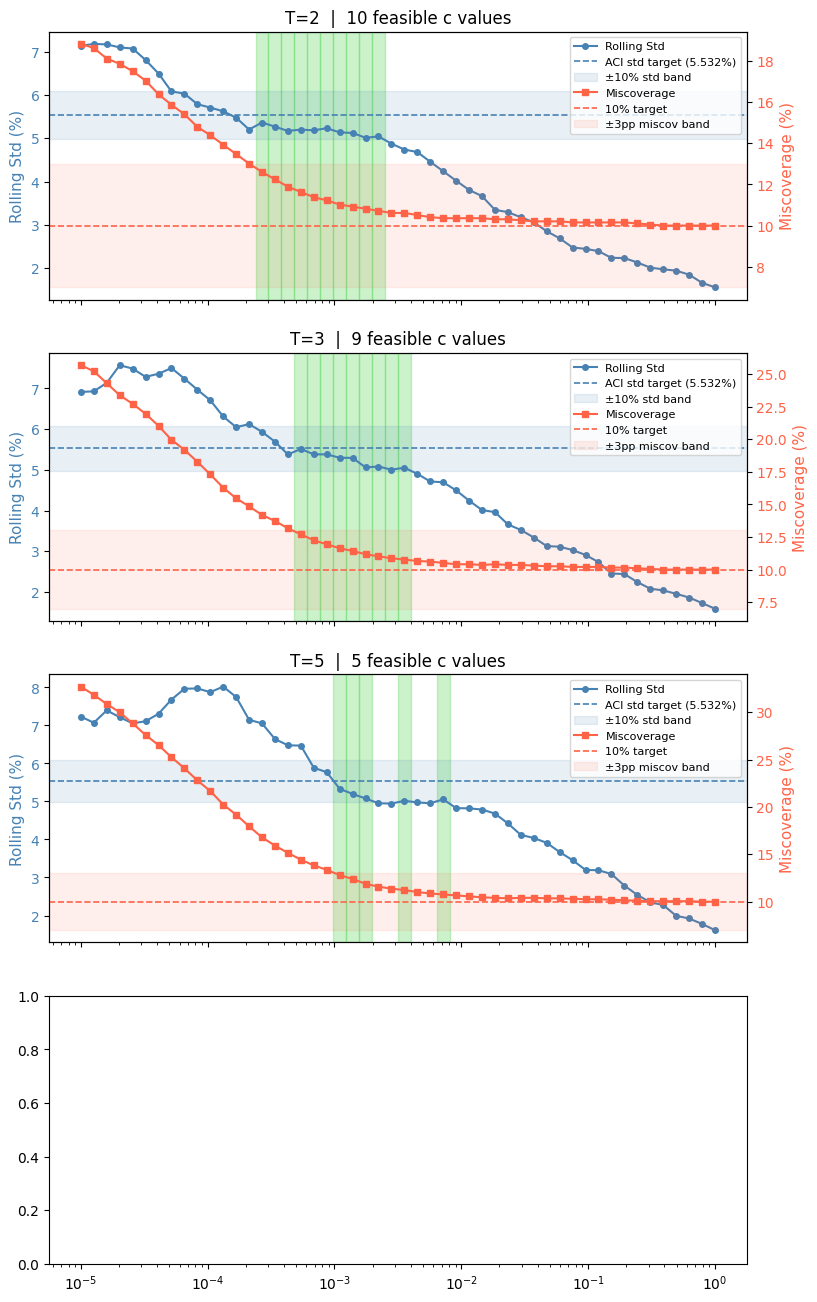

In [9]:
"""
BCI TRENDS 1D DIAGNOSTIC: rolling std AND miscoverage vs c
===========================================================
Plots both metrics on the same c grid so you can see whether
there's any c that simultaneously hits the ACI std target
and keeps miscoverage near 10%.

Focuses the grid around the std-crossing region seen in the
advisor's plot: c in [1e-5, 1e0], 50 points.
"""

import numpy as np
import pandas as pd
import sys
import logging
import matplotlib.pyplot as plt

from utils import read_yaml
from experiment import ForecastingExperiment

logging.getLogger().setLevel(logging.WARNING)
sys.setrecursionlimit(10000)

ALPHA_BAR  = 0.1
BURNIN     = 100
SEARCH_END = 100
EVAL_ROLL  = 50

TASK       = 'trend'
DATASET    = 'unknown'
ACI_GAMMA  = 0.008   # change to 0.1 to check that case too

# Focus around the crossing region — finer than before
C_GRID = np.geomspace(1e-5, 1e0, 50)

MISCOV_TOL = 0.03   # acceptable miscov band around 10%

# =============================================================================
# HELPERS
# =============================================================================

def _err_ind(df):
    a = pd.to_numeric(df['alpha'], errors='coerce')
    b = pd.to_numeric(df['beta'],  errors='coerce')
    return (a > b).astype(float)


def compute_metrics(result_df):
    df     = result_df.iloc[BURNIN:].copy()
    ei     = _err_ind(df)
    miscov = float(ei.mean())
    std    = float(ei.rolling(window=EVAL_ROLL, min_periods=1).mean().std())
    return miscov, std


def flatten_yaml(cfg):
    for k, v in list(cfg.items()):
        if isinstance(v, list) and len(v) == 1:
            cfg[k] = v[0]
    return cfg


def run_bci(bci_cfg_raw, lambda_max, c, T):
    cfg = dict(bci_cfg_raw)
    cfg['lambda_max']  = float(lambda_max)
    cfg['lambda_init'] = float(0.01 * lambda_max)
    cfg['gamma']       = float(c * lambda_max)
    cfg['T']           = int(T)
    exp = ForecastingExperiment(cfg)
    exp.run()
    return exp.result


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":

    # ── Load configs ──
    aci_cfg     = flatten_yaml(read_yaml(f'config/{TASK}-aci.yaml'))
    bci_cfg_raw = flatten_yaml(read_yaml(f'config/{TASK}-bci.yaml'))
    for k in ['lambda_max', 'lambda_init', 'gamma']:
        bci_cfg_raw.pop(k, None)

    aci_cfg['gamma'] = ACI_GAMMA

    # ── ACI target ──
    exp_aci = ForecastingExperiment(aci_cfg)
    exp_aci.run()
    aci_miscov, aci_std = compute_metrics(exp_aci.result)
    print(f"ACI: miscov={aci_miscov*100:.2f}%  std={aci_std*100:.3f}%  <-- targets")

    # ── Load lambda_max from CSV (same value your main script uses) ──
    # Update these to match your CSV values for trend/unknown/gamma
    LAMBDA_MAX = 2.92e3   # <-- update to your CSV lmax for this gamma

    # ── Sweep T values separately ──
    T_VALS = [2, 3, 5, 7]

    fig, axes = plt.subplots(len(T_VALS), 1, figsize=(9, 4 * len(T_VALS)), sharex=True)

    all_feasible = {}

    for ax, T in zip(axes, T_VALS):
        print(f"\n  Sweeping T={T} over {len(C_GRID)} c values...")
        miscovs = []
        stds    = []

        for i, c in enumerate(C_GRID):
            res = run_bci(bci_cfg_raw, LAMBDA_MAX, c, T)
            miscov, std = compute_metrics(res)
            miscovs.append(miscov)
            stds.append(std)
            if (i+1) % 10 == 0:
                print(f"    {i+1}/{len(C_GRID)}  c={c:.2e}  "
                      f"miscov={miscov*100:.2f}%  std={std*100:.3f}%")

        miscovs = np.array(miscovs)
        stds    = np.array(stds)

        # Feasible: both conditions met
        miscov_ok  = np.abs(miscovs - ALPHA_BAR) <= MISCOV_TOL
        std_ok     = np.abs(stds - aci_std) / (aci_std + 1e-12) <= 0.10
        both_ok    = miscov_ok & std_ok
        n_feasible = both_ok.sum()
        all_feasible[T] = n_feasible

        print(f"    T={T}: {n_feasible}/{len(C_GRID)} feasible c values")
        if n_feasible > 0:
            best_c = C_GRID[both_ok][np.argmin(np.abs(stds[both_ok] - aci_std))]
            print(f"    Best feasible c={best_c:.4e}  "
                  f"miscov={miscovs[C_GRID==best_c][0]*100:.2f}%  "
                  f"std={stds[C_GRID==best_c][0]*100:.3f}%")

        # ── Plot ──
        color_std    = 'steelblue'
        color_miscov = 'tomato'

        ax2 = ax.twinx()

        ax.plot(C_GRID, stds * 100, '-o', color=color_std,
                markersize=4, linewidth=1.5, label='Rolling Std')
        ax.axhline(y=aci_std * 100, color=color_std, linestyle='--',
                   linewidth=1.2, label=f'ACI std target ({aci_std*100:.3f}%)')
        ax.axhspan((aci_std * 0.9) * 100, (aci_std * 1.1) * 100,
                   alpha=0.12, color=color_std, label='±10% std band')

        ax2.plot(C_GRID, miscovs * 100, '-s', color=color_miscov,
                 markersize=4, linewidth=1.5, label='Miscoverage')
        ax2.axhline(y=ALPHA_BAR * 100, color=color_miscov, linestyle='--',
                    linewidth=1.2, label='10% target')
        ax2.axhspan((ALPHA_BAR - MISCOV_TOL) * 100, (ALPHA_BAR + MISCOV_TOL) * 100,
                    alpha=0.10, color=color_miscov, label=f'±{MISCOV_TOL*100:.0f}pp miscov band')

        # Shade feasible region
        if n_feasible > 0:
            for k, c_val in enumerate(C_GRID):
                if both_ok[k]:
                    ax.axvspan(
                        c_val * (C_GRID[k-1]/c_val)**0.5 if k > 0 else c_val * 0.5,
                        c_val * (C_GRID[k+1]/c_val)**0.5 if k < len(C_GRID)-1 else c_val * 2,
                        alpha=0.25, color='limegreen', zorder=0
                    )

        ax.set_xscale('log')
        ax.set_ylabel('Rolling Std (%)', color=color_std, fontsize=11)
        ax2.set_ylabel('Miscoverage (%)', color=color_miscov, fontsize=11)
        ax.tick_params(axis='y', labelcolor=color_std)
        ax2.tick_params(axis='y', labelcolor=color_miscov)

        # Combined legend
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2,
                  loc='upper right', fontsize=8)

        feasible_str = f"{n_feasible} feasible c values" if n_feasible > 0 \
                       else "NO feasible c found"
        ax.set_title(f'T={T}  |  {feasible_str}', fontsize=12)

    axes[-1].set_xlabel('c (Learning Rate Multiplier)', fontsize=12)
    fig.suptitle(
        f'BCI Trends Diagnostic: miscov & std vs c\n'
        f'gamma={ACI_GAMMA}, lambda_max={LAMBDA_MAX:.2e}',
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    plt.savefig(f'bci_trends_1d_diagnostic_gamma{ACI_GAMMA}.pdf',
                dpi=200, bbox_inches='tight')
    plt.close()

    print(f"\n{'='*60}")
    print(f"  FEASIBILITY SUMMARY — gamma={ACI_GAMMA}")
    print(f"{'='*60}")
    for T, n in all_feasible.items():
        status = "OK" if n > 0 else "NO FEASIBLE c"
        print(f"  T={T}: {n}/{len(C_GRID)} feasible c values  -->  {status}")
    print(f"{'='*60}")
    print(f"\n  Saved: bci_trends_1d_diagnostic_gamma{ACI_GAMMA}.pdf")

In [12]:
"""
PRODUCTION SCRIPT: Conformal Prediction Batch Run (RTFC)
=========================================================
BCI lambda_max and c loaded from CSV.
PID eta and ki hardcoded from 30x30 grid search results.
No tuning at runtime.

Note: rtfc Amazon/AMD/Nvidia gamma=0.008 are structurally infeasible
(data volatility ceiling below ACI target). Best-effort values used.
"""

import numpy as np
import pandas as pd
import sys
import logging
import matplotlib.pyplot as plt

from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log
from visualize import gen_plot_data

logging.getLogger().setLevel(logging.WARNING)
sys.setrecursionlimit(10000)

ALPHA_BAR  = 0.1
BURNIN     = 100
SEARCH_END = 100
PLOT_ROLL  = 250
EVAL_ROLL  = 50

# Hardcoded PID params from 30x30 grid search
# (*) = structurally infeasible, best-effort value used
PID_PARAMS = {
    ('Amazon', 0.1):  {'eta': 9.237e-02, 'ki': 3.562e-02},
    ('Amazon', 0.008):{'eta': 1.374e-02, 'ki': 6.723e-06},  # (*)
    ('AMD',    0.1):  {'eta': 7.880e-04, 'ki': 1.374e-02},
    ('AMD',    0.008):{'eta': 3.562e-02, 'ki': 6.723e-06},  # (*)
    ('Nvidia', 0.1):  {'eta': 1.374e-02, 'ki': 2.395e-01},
    ('Nvidia', 0.008):{'eta': 3.562e-02, 'ki': 1.172e-04},  # (*)
}

INFEASIBLE = {('Amazon', 0.008), ('AMD', 0.008), ('Nvidia', 0.008)}

# =============================================================================
# CSV LOADING
# =============================================================================

def load_csv_params(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    for col in ['Task', 'Dataset', 'method']:
        if col in df.columns:
            df[col] = df[col].str.strip()
    df['T'] = df['T'].apply(lambda x: -1 if str(x).strip() in ('-', '', 'nan') else int(x))
    df['Gamma_Target'] = pd.to_numeric(df['Gamma_Target'], errors='coerce')
    for col in ['lmax', 'c']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    key_cols = ['Task', 'Dataset', 'Gamma_Target', 'method', 'T']
    n_before = len(df)
    df = df.drop_duplicates(subset=key_cols, keep='first').reset_index(drop=True)
    n_after = len(df)
    if n_before != n_after:
        print(f"  [CSV] Deduplicated {n_before} -> {n_after} rows")
    return df


def lookup_bci_params(csv_df, task, dataset, gamma, T):
    method_str = f'BCI(T={T})'
    mask = (
        (csv_df['Task'].str.lower()     == task.lower()) &
        (csv_df['Dataset']               == dataset) &
        (csv_df['Gamma_Target'].round(6) == round(gamma, 6)) &
        (csv_df['method']                == method_str) &
        (csv_df['T']                     == T)
    )
    rows = csv_df[mask]
    if rows.empty:
        raise ValueError(f"No CSV row for task={task}, dataset={dataset}, "
                         f"gamma={gamma}, method={method_str}, T={T}")
    row = rows.iloc[0]
    return float(row['lmax']), float(row['c'])


# =============================================================================
# HELPERS
# =============================================================================

def clean_df(df):
    for col in ['upper', 'lower', 'true_y', 'alpha', 'beta']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


def _err_ind(df):
    alpha = pd.to_numeric(df['alpha'], errors='coerce')
    beta  = pd.to_numeric(df['beta'],  errors='coerce')
    return (alpha > beta).astype(float)


# =============================================================================
# METRICS
# =============================================================================

def compute_full_miscov_std(result_df):
    df = result_df.iloc[BURNIN:].copy()
    return float(_err_ind(df).rolling(window=EVAL_ROLL, min_periods=1).mean().std())


def compute_metrics_after_burnin(result_df):
    df    = result_df.iloc[BURNIN:].copy()
    ei    = _err_ind(df)
    upper = pd.to_numeric(df['upper'], errors='coerce')
    lower = pd.to_numeric(df['lower'], errors='coerce')
    local_miscov  = ei.rolling(window=EVAL_ROLL, min_periods=1).mean()
    raw_lengths   = upper - lower
    valid_lengths = raw_lengths[np.isfinite(raw_lengths)]
    return (float(ei.mean()),
            float(local_miscov.std()),
            float(valid_lengths.mean() if len(valid_lengths) > 0 else np.nan))


def starting_miscov_at_burnin(result_df, window=50):
    df = result_df.iloc[BURNIN:BURNIN + window].copy()
    return float(_err_ind(df).mean())


# =============================================================================
# RUNNERS
# =============================================================================

def run_pid(scores, y_pred_center, y_true, eta, csat, ki):
    """RTFC: lower not clipped."""
    pid_out = quantile_integrator_log(
        scores=scores, alpha=ALPHA_BAR, lr=eta,
        Csat=csat, KI=ki, ahead=1, T_burnin=SEARCH_END
    )
    q     = np.maximum(np.array(pid_out['q']), 0.0)
    upper = y_pred_center + q
    lower = y_pred_center - q
    beta  = ((y_true >= lower) & (y_true <= upper)).astype(int)
    df = pd.DataFrame({
        'alpha': ALPHA_BAR, 'beta': beta,
        'upper': upper, 'lower': lower, 'true_y': y_true
    })
    df['lambda'] = np.nan
    return df


def run_bci_with_params(exp_config, lambda_max, c, T):
    cfg = dict(exp_config)
    cfg['lambda_max']  = float(lambda_max)
    cfg['lambda_init'] = float(0.01 * lambda_max)
    cfg['gamma']       = float(c * lambda_max)
    cfg['T']           = int(T)
    exp = ForecastingExperiment(cfg)
    exp.run()
    return exp.result


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    CSV_PATH = "Master_BCI_Results_Organized.csv"
    T_vals   = [2, 3, 5]
    task     = 'rtfc'
    datasets = ['AMD', 'Amazon', 'Nvidia']
    xform    = lambda x: x.astype(float)
    gamma_vals = [0.1, 0.008]

    print(f"Loading pre-tuned params from: {CSV_PATH}")
    csv_df = load_csv_params(CSV_PATH)
    print(f"  {len(csv_df)} unique rows loaded.\n")

    for dataset in datasets:
        for ACI_GAMMA in gamma_vals:
            print(f"\n\n{'='*85}")
            print(f"### Task={task.upper()} | Dataset={dataset} | ACI gamma={ACI_GAMMA}")
            if (dataset, ACI_GAMMA) in INFEASIBLE:
                print(f"  NOTE: PID infeasible for this case -- using best-effort params")
            print(f"  BCI params from CSV, PID params hardcoded")
            print(f"{'='*85}\n")

            aci_cfg          = read_yaml(f'config/{task}-aci-{dataset}.yaml')
            aci_cfg['gamma'] = ACI_GAMMA
            fixed_cfg        = read_yaml(f'config/{task}-fixed-{dataset}.yaml')
            bci_cfg_raw      = read_yaml(f'config/{task}-bci-{dataset}.yaml')
            for key in ['lambda_max', 'lambda_init', 'gamma']:
                bci_cfg_raw.pop(key, None)

            exp_fixed = ForecastingExperiment(fixed_cfg)
            exp_fixed.run()

            y_true        = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
            upper_f       = pd.to_numeric(exp_fixed.result['upper'],  errors='coerce').values
            lower_f       = pd.to_numeric(exp_fixed.result['lower'],  errors='coerce').values
            y_pred_center = (upper_f + lower_f) / 2
            scores        = np.abs(y_true - y_pred_center)
            T_len         = len(y_true)
            csat_formula  = max((2/np.pi)*(np.ceil(np.log(T_len)*0.05) - 1/np.log(T_len)), 0.1)
            csat          = min(csat_formula, np.percentile(scores, 99))

            temp_fixed          = exp_fixed.result.copy()
            temp_fixed['alpha'] = ALPHA_BAR
            temp_fixed['beta']  = (
                (pd.to_numeric(temp_fixed['true_y']) >= pd.to_numeric(temp_fixed['lower'])) &
                (pd.to_numeric(temp_fixed['true_y']) <= pd.to_numeric(temp_fixed['upper']))
            ).astype(int)
            temp_fixed['lambda'] = np.nan

            fixed_m, fixed_s, fixed_l = compute_metrics_after_burnin(temp_fixed)
            fixed_paper_std           = compute_full_miscov_std(temp_fixed)
            fixed_start               = starting_miscov_at_burnin(temp_fixed)

            exp_aci = ForecastingExperiment(aci_cfg)
            exp_aci.run()
            aci_std             = compute_full_miscov_std(exp_aci.result)
            aci_m, aci_s, aci_l = compute_metrics_after_burnin(exp_aci.result)
            aci_start           = starting_miscov_at_burnin(exp_aci.result)
            print(f"  ACI miscov={aci_m*100:.2f}% | length={aci_l:.6f} | std={aci_std:.6f}")

            pid_p             = PID_PARAMS[(dataset, ACI_GAMMA)]
            best_eta, best_ki = pid_p['eta'], pid_p['ki']
            print(f"  PID using hardcoded eta={best_eta:.3e}, ki={best_ki:.3e}")
            pid_df = run_pid(scores, y_pred_center, y_true, best_eta, csat, best_ki)
            pid_df.index = exp_fixed.result.index

            pid_m, pid_s, pid_l = compute_metrics_after_burnin(pid_df)
            pid_paper_std        = compute_full_miscov_std(pid_df)
            pid_start            = starting_miscov_at_burnin(pid_df)
            print(f"  PID miscov={pid_m*100:.2f}% | length={pid_l:.6f} | std={pid_paper_std:.6f}\n")

            bci_rows   = {}
            p_bci_dict = {}
            ma_win = PLOT_ROLL
            x_skip = 300

            for T in T_vals:
                try:
                    lambda_max, c = lookup_bci_params(csv_df, task, dataset, ACI_GAMMA, T)
                except ValueError as e:
                    print(f"  SKIPPING T={T}: {e}")
                    continue
                print(f"  BCI T={T}: lambda_max={lambda_max:.4e}, c={c:.4e}")
                res = run_bci_with_params(bci_cfg_raw, lambda_max, c, T)
                m, s, l   = compute_metrics_after_burnin(res)
                paper_std = compute_full_miscov_std(res)
                start     = starting_miscov_at_burnin(res)
                p_bci_dict[T] = gen_plot_data(
                    clean_df(res.iloc[BURNIN:].copy()), ma_win, x_skip, xform)
                bci_rows[T] = {'T': T, 'c': c, 'lambda_max': lambda_max,
                               'paper_std': paper_std, 'm': m, 's': s,
                               'l': l, 'start': start}
                print(f"         miscov={m*100:.2f}% | length={l:.6f} | std={paper_std:.6f}")

            if not p_bci_dict:
                print("  No BCI results -- skipping plots.")
                continue

            p_fixed = gen_plot_data(clean_df(temp_fixed.iloc[BURNIN:]), ma_win, x_skip, xform)
            p_aci   = gen_plot_data(clean_df(exp_aci.result.iloc[BURNIN:].copy()), ma_win, x_skip, xform)
            p_pid   = gen_plot_data(clean_df(pid_df.iloc[BURNIN:]), ma_win, x_skip, xform)
            last_T  = max(p_bci_dict.keys())
            last_p  = p_bci_dict[last_T]

            print(f"\n{'='*100}")
            print(f"  RESULTS -- {dataset} ({task.upper()}, gamma={ACI_GAMMA}, burn-in={BURNIN})")
            print(f"{'='*100}")
            print(f"{'Method':<20} {'Params':<35} {'Miscov%':>8} {'PaperStd%':>11} {'Length':>10} {'StartMiscov%':>14}")
            print(f"{'-'*100}")
            print(f"{'Fixed':<20} {'-':<35} {fixed_m*100:>7.2f}% {fixed_paper_std*100:>10.3f}% {fixed_l:>10.4f} {fixed_start*100:>13.2f}%")
            print(f"{'ACI':<20} {'gamma='+str(ACI_GAMMA):<35} {aci_m*100:>7.2f}% {aci_std*100:>10.3f}% {aci_l:>10.4f} {aci_start*100:>13.2f}%")
            infeas_note = ' (*)' if (dataset, ACI_GAMMA) in INFEASIBLE else ''
            print(f"{'PID'+infeas_note:<20} {f'eta={best_eta:.4f}, ki={best_ki:.4f}':<35} {pid_m*100:>7.2f}% {pid_paper_std*100:>10.3f}% {pid_l:>10.4f} {pid_start*100:>13.2f}%")
            print(f"{'-'*100}")
            for T, r in sorted(bci_rows.items()):
                label = f"BCI (T={r['T']})"
                param = f"lmax={r['lambda_max']:.3e}, c={r['c']:.4e}"
                print(f"{label:<20} {param:<35} {r['m']*100:>7.2f}% {r['paper_std']*100:>10.3f}% {r['l']:>10.4f} {r['start']*100:>13.2f}%")
            print(f"{'='*100}\n")
            if INFEASIBLE & {(dataset, ACI_GAMMA)}:
                print(f"  (*) PID structurally infeasible for this case -- data volatility ceiling below ACI target\n")

            # Plot 1: Baselines
            fig1, axs1 = plt.subplots(2, 1, figsize=(7, 10))
            ref_T = 3 if 3 in p_bci_dict else last_T
            axs1[0].plot(100*p_aci['miscovrate'],             '-',  color='navy',        label='ACI',              linewidth=1.5)
            axs1[0].plot(100*p_bci_dict[ref_T]['miscovrate'], '-',  color='tomato',      label=f'BCI (T={ref_T})', linewidth=1.5)
            axs1[0].plot(100*p_fixed['miscovrate'],           '-',  color='silver',      label='Fixed',            linewidth=1.5)
            axs1[0].plot(100*p_pid['miscovrate'],             '--', color='forestgreen', label='PID',              linewidth=1.5)
            axs1[0].axhline(y=100*ALPHA_BAR, color='gray', linestyle='--', linewidth=1, zorder=0)
            axs1[0].set_ylabel('Mis-coverage rate (%)', fontsize=14)
            axs1[0].legend(loc='upper right', prop={'size': 11})
            axs1[0].set_xticks(last_p['indices'])
            axs1[0].set_xticklabels([last_p['date_indices'][j] for j in last_p['indices']], rotation=30, fontsize=11)
            axs1[0].set_ylim(bottom=1.5, top=max(100*p_aci['miscovrate'].max(), 13))
            axs1[1].plot(p_aci['length'],             '-',  color='navy',        label='ACI',              linewidth=1.5)
            axs1[1].plot(p_bci_dict[ref_T]['length'], '-',  color='tomato',      label=f'BCI (T={ref_T})', linewidth=1.5)
            axs1[1].plot(p_fixed['length'],           '-',  color='silver',      label='Fixed',            linewidth=1.5)
            axs1[1].plot(p_pid['length'],             '-',  color='forestgreen', label='PID',              linewidth=1.5)
            axs1[1].set_ylabel('Interval Length', fontsize=14)
            axs1[1].legend(loc='upper right', prop={'size': 11})
            axs1[1].set_xticks(last_p['indices'])
            axs1[1].set_xticklabels([last_p['date_indices'][j] for j in last_p['indices']], rotation=30, fontsize=11)
            for ax in range(2):
                for lbl in axs1[ax].get_yticklabels(): lbl.set_fontsize(11)
                for spine in axs1[ax].spines.values(): spine.set_edgecolor('gray')
            fig1.suptitle(rf'Return forecasting for {dataset} ($\gamma={ACI_GAMMA}$)', fontsize=16, y=0.96)
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.savefig(f'plot1_baselines_{task}_{dataset}_gamma{ACI_GAMMA}.pdf', dpi=300, bbox_inches='tight')
            plt.close(fig1)

            # Plot 2: BCI Horizon Sweep
            fig2, axs2 = plt.subplots(2, 1, figsize=(7, 10))
            colors_t = ['tomato', 'forestgreen', 'navy']
            styles_t = ['-', '--', ':']
            for i, T_val in enumerate(sorted(p_bci_dict.keys())):
                ls  = styles_t[i % len(styles_t)]
                col = colors_t[i % len(colors_t)]
                axs2[0].plot(100*p_bci_dict[T_val]['miscovrate'], ls, color=col, label=f'BCI (T={T_val})', linewidth=1.5)
                axs2[1].plot(p_bci_dict[T_val]['length'],         ls, color=col, label=f'BCI (T={T_val})', linewidth=1.5)
            axs2[0].axhline(y=100*ALPHA_BAR, color='gray', linestyle='--', linewidth=1, zorder=0)
            axs2[0].set_ylabel('Mis-coverage rate (%)', fontsize=14)
            axs2[0].legend(loc='upper right', prop={'size': 11})
            axs2[0].set_xticks(last_p['indices'])
            axs2[0].set_xticklabels([last_p['date_indices'][j] for j in last_p['indices']], rotation=30, fontsize=11)
            axs2[1].set_ylabel('Interval Length', fontsize=14)
            axs2[1].legend(loc='upper right', prop={'size': 11})
            axs2[1].set_xticks(last_p['indices'])
            axs2[1].set_xticklabels([last_p['date_indices'][j] for j in last_p['indices']], rotation=30, fontsize=11)
            for ax in range(2):
                for lbl in axs2[ax].get_yticklabels(): lbl.set_fontsize(11)
                for spine in axs2[ax].spines.values(): spine.set_edgecolor('gray')
            fig2.suptitle(rf'BCI Horizon Sweep for {dataset} ($\gamma={ACI_GAMMA}$)', fontsize=16, y=0.96)
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.savefig(f'plot2_sweep_{task}_{dataset}_gamma{ACI_GAMMA}.pdf', dpi=300, bbox_inches='tight')
            plt.close(fig2)

Loading pre-tuned params from: Master_BCI_Results_Organized.csv
  [CSV] Deduplicated 67 -> 58 rows
  58 unique rows loaded.



### Task=RTFC | Dataset=AMD | ACI gamma=0.1
  BCI params from CSV, PID params hardcoded

  ACI miscov=9.95% | length=0.112845 | std=0.027267
  PID using hardcoded eta=7.880e-04, ki=1.374e-02


100%|██████████| 2834/2834 [00:00<00:00, 172417.83it/s]

  PID miscov=11.34% | length=0.154939 | std=0.027244

  BCI T=2: lambda_max=3.4161e+01, c=1.4251e-02


         miscov=9.91% | length=0.103434 | std=0.026187
  BCI T=3: lambda_max=3.4161e+01, c=2.8943e-02
         miscov=9.95% | length=0.105118 | std=0.024795
  BCI T=5: lambda_max=3.4161e+01, c=5.8780e-02
         miscov=9.91% | length=0.103658 | std=0.027444

  RESULTS -- AMD (RTFC, gamma=0.1, burn-in=100)
Method               Params                               Miscov%   PaperStd%     Length   StartMiscov%
----------------------------------------------------------------------------------------------------
Fixed                -                                      7.53%      4.867%     0.1175          8.00%
ACI                  gamma=0.1                              9.95%      2.727%     0.1128          8.00%
PID                  eta=0.0008, ki=0.0137                 11.34%      2.724%     0.1549         10.00%
----------------------------------------------------------------------------------------------------
BCI (T=2)            lmax=3.416e+01, c=1.4251e-02           9.91%      2.6

100%|██████████| 2834/2834 [00:00<00:00, 174590.68it/s]

...

  PID miscov=10.18% | length=0.102624 | std=0.026679

  BCI T=2: lambda_max=2.3087e+01, c=1.4251e-02


         miscov=10.04% | length=0.084759 | std=0.028814
  BCI T=3: lambda_max=2.3087e+01, c=2.8943e-02
         miscov=10.04% | length=0.086472 | std=0.027602
  BCI T=5: lambda_max=2.3087e+01, c=5.8780e-02
         miscov=10.07% | length=0.086772 | std=0.029390

  RESULTS -- Nvidia (RTFC, gamma=0.1, burn-in=100)
Method               Params                               Miscov%   PaperStd%     Length   StartMiscov%
----------------------------------------------------------------------------------------------------
Fixed                -                                      6.83%      6.888%     0.1017          2.00%
ACI                  gamma=0.1                             10.04%      2.680%     0.0928         10.00%
PID                  eta=0.0137, ki=0.2395                 10.18%      2.668%     0.1026         12.00%
----------------------------------------------------------------------------------------------------
BCI (T=2)            lmax=2.309e+01, c=1.4251e-02          10.04%   

100%|██████████| 3058/3058 [00:00<00:00, 154079.35it/s]

  PID miscov=10.38% | length=0.086166 | std=0.043076

  BCI T=2: lambda_max=2.3087e+01, c=8.3768e-04


         miscov=10.31% | length=0.082164 | std=0.062970
  BCI T=3: lambda_max=2.3087e+01, c=1.7013e-03
         miscov=10.28% | length=0.082201 | std=0.060841
  BCI T=5: lambda_max=2.3087e+01, c=3.4551e-03
         miscov=10.34% | length=0.082424 | std=0.061567

  RESULTS -- Nvidia (RTFC, gamma=0.008, burn-in=100)
Method               Params                               Miscov%   PaperStd%     Length   StartMiscov%
----------------------------------------------------------------------------------------------------
Fixed                -                                      6.83%      6.888%     0.1017          2.00%
ACI                  gamma=0.008                           10.07%      6.259%     0.0896          4.00%
PID (*)              eta=0.0356, ki=0.0001                 10.38%      4.308%     0.0862         14.00%
----------------------------------------------------------------------------------------------------
BCI (T=2)            lmax=2.309e+01, c=8.3768e-04          10.31% 

In [13]:
"""
PID RTFC gamma=0.008: NEW TUNING LOGIC
========================================
Same idea as new BCI tuning:
  Stage 1: Find all (eta, ki) where |miscov - 0.1| <= 0.001 (within +-0.1%)
  Stage 2: Among those, pick (eta, ki) with std closest to ACI's

Rationale: PID can achieve tight marginal coverage with lower variance than
ACI gamma=0.008. Old tuning penalized this by forcing it to match ACI std.
New approach lets PID be as stable as it wants while staying calibrated.

Only runs rtfc gamma=0.008 for Amazon, AMD, Nvidia.
No plots -- just verify the new logic produces sensible results.
"""

import numpy as np
import pandas as pd
import sys
import logging

from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log

logging.getLogger().setLevel(logging.WARNING)
sys.setrecursionlimit(10000)

ALPHA_BAR  = 0.1
BURNIN     = 100
SEARCH_END = 100
EVAL_ROLL  = 50
GRID_SIZE  = 30         # 30x30 = 900 points
MISCOV_TOL = 0.001      # tight: within 0.1% of 10%

# =============================================================================
# HELPERS
# =============================================================================

def _err_ind(df):
    a = pd.to_numeric(df['alpha'], errors='coerce')
    b = pd.to_numeric(df['beta'],  errors='coerce')
    return (a > b).astype(float)


def compute_miscov_std(result_df):
    df     = result_df.iloc[BURNIN:].copy()
    ei     = _err_ind(df)
    miscov = float(ei.mean())
    std    = float(ei.rolling(window=EVAL_ROLL, min_periods=1).mean().std())
    return miscov, std


def run_pid(scores, y_pred_center, y_true, eta, csat, ki):
    """RTFC: lower not clipped."""
    pid_out = quantile_integrator_log(
        scores=scores, alpha=ALPHA_BAR, lr=eta,
        Csat=csat, KI=ki, ahead=1, T_burnin=SEARCH_END
    )
    q     = np.maximum(np.array(pid_out['q']), 0.0)
    upper = y_pred_center + q
    lower = y_pred_center - q
    beta  = ((y_true >= lower) & (y_true <= upper)).astype(int)
    return pd.DataFrame({
        'alpha': ALPHA_BAR, 'beta': beta,
        'upper': upper, 'lower': lower, 'true_y': y_true,
        'lambda': np.nan
    })


def tune_pid_new(scores, y_pred_center, y_true, csat, aci_std, tol=MISCOV_TOL):
    """
    New tuning logic:
      1. Sweep full 30x30 grid
      2. Filter to cells where miscov is within tol of 10%
      3. Among those, pick (eta, ki) with std closest to ACI's
      4. If nothing passes, relax tol to 1% then fall back to old scoring
    """
    etas = np.geomspace(1e-6, 1e6, GRID_SIZE)
    kis  = np.geomspace(1e-6, 1e6, GRID_SIZE)

    miscov_grid = np.zeros((GRID_SIZE, GRID_SIZE))
    std_grid    = np.zeros((GRID_SIZE, GRID_SIZE))
    done = 0

    for i, eta in enumerate(etas):
        for j, ki in enumerate(kis):
            df = run_pid(scores, y_pred_center, y_true, eta, csat, ki)
            miscov, std = compute_miscov_std(df)
            miscov_grid[i, j] = miscov
            std_grid[i, j]    = std
            done += 1
            if done % 100 == 0:
                print(f"    {done}/900 pairs done...", flush=True)

    # Stage 1: filter to calibrated cells
    calibrated = np.abs(miscov_grid - ALPHA_BAR) <= tol
    n_calibrated = calibrated.sum()

    if n_calibrated == 0:
        print(f"    No cells within +-{tol*100:.1f}% -- relaxing to +-1%")
        tol = 0.01
        calibrated = np.abs(miscov_grid - ALPHA_BAR) <= tol
        n_calibrated = calibrated.sum()

    if n_calibrated == 0:
        print(f"    Still none -- falling back to old scoring")
        # Old scoring: penalize miscoverage deviation
        score_grid = np.abs(std_grid - aci_std)
        miscov_dev = np.abs(miscov_grid - ALPHA_BAR)
        score_grid = np.where(miscov_dev <= 0.03,
                              score_grid,
                              score_grid + 5.0 * miscov_dev)
        best_flat = np.argmin(score_grid)
    else:
        # Stage 2: among calibrated, pick closest std
        std_diff = np.abs(std_grid - aci_std)
        std_diff_masked = np.where(calibrated, std_diff, np.inf)
        best_flat = np.argmin(std_diff_masked)

    bi, bj = np.unravel_index(best_flat, miscov_grid.shape)
    return (etas[bi], kis[bj],
            miscov_grid[bi, bj], std_grid[bi, bj],
            n_calibrated)


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":

    datasets   = ['Amazon', 'AMD', 'Nvidia']
    ACI_GAMMA  = 0.008
    task       = 'rtfc'

    rows = []

    for dataset in datasets:
        print(f"\n{'='*65}")
        print(f"  {task.upper()} | {dataset} | gamma={ACI_GAMMA}")
        print(f"{'='*65}")

        aci_cfg          = read_yaml(f'config/{task}-aci-{dataset}.yaml')
        aci_cfg['gamma'] = ACI_GAMMA
        fixed_cfg        = read_yaml(f'config/{task}-fixed-{dataset}.yaml')

        exp_fixed = ForecastingExperiment(fixed_cfg)
        exp_fixed.run()

        y_true        = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
        upper_f       = pd.to_numeric(exp_fixed.result['upper'],  errors='coerce').values
        lower_f       = pd.to_numeric(exp_fixed.result['lower'],  errors='coerce').values
        y_pred_center = (upper_f + lower_f) / 2
        scores        = np.abs(y_true - y_pred_center)
        T_len         = len(y_true)
        csat_formula  = max((2/np.pi)*(np.ceil(np.log(T_len)*0.05) - 1/np.log(T_len)), 0.1)
        csat          = min(csat_formula, np.percentile(scores, 99))

        exp_aci = ForecastingExperiment(aci_cfg)
        exp_aci.run()
        aci_miscov, aci_std = compute_miscov_std(exp_aci.result)
        print(f"  ACI: miscov={aci_miscov*100:.2f}%  std={aci_std*100:.3f}%  <-- target")

        print(f"  Sweeping 30x30 grid...")
        best_eta, best_ki, pid_miscov, pid_std, n_cal = tune_pid_new(
            scores, y_pred_center, y_true, csat, aci_std
        )

        print(f"  --> eta={best_eta:.4e}, ki={best_ki:.4e} | "
              f"miscov={pid_miscov*100:.2f}% | std={pid_std*100:.3f}% "
              f"(ACI={aci_std*100:.3f}%) | {n_cal}/900 calibrated cells")

        rows.append({
            'dataset':    dataset,
            'aci_miscov': aci_miscov, 'aci_std': aci_std,
            'pid_miscov': pid_miscov, 'pid_std': pid_std,
            'eta':        best_eta,   'ki':      best_ki,
            'n_cal':      n_cal,
        })

    # Summary
    print(f"\n\n{'='*105}")
    print("  SUMMARY -- New PID tuning (coverage-first, then closest std) | rtfc gamma=0.008")
    print(f"{'='*105}")
    print(f"{'Dataset':<10} {'ACI Miscov':>11} {'ACI Std':>9} "
          f"{'PID Miscov':>11} {'PID Std':>9} "
          f"{'eta':>10} {'ki':>10} {'N calib':>8}")
    print(f"{'-'*105}")
    for r in rows:
        print(f"{r['dataset']:<10} "
              f"{r['aci_miscov']*100:>10.2f}% {r['aci_std']*100:>8.3f}% "
              f"{r['pid_miscov']*100:>10.2f}% {r['pid_std']*100:>8.3f}% "
              f"{r['eta']:>10.4e} {r['ki']:>10.4e} {r['n_cal']:>8}")
    print(f"{'='*105}")
    print(f"\n  Note: N calib = number of (eta,ki) pairs where |miscov - 10%| <= 0.1%")
    print(f"        std reported is the closest achievable to ACI among calibrated pairs")


  RTFC | Amazon | gamma=0.008
  ACI: miscov=10.02%  std=6.600%  <-- target
  Sweeping 30x30 grid...


100%|██████████| 3762/3762 [00:00<00:00, 182931.87it/s]

    100/900 pairs done...



100%|██████████| 3762/3762 [00:00<00:00, 177789.23it/s]

    200/900 pairs done...


...

    700/900 pairs done...



100%|██████████| 3058/3058 [00:00<00:00, 186793.59it/s]

    800/900 pairs done...



100%|██████████| 3058/3058 [00:00<00:00, 177542.21it/s]


    900/900 pairs done...
  --> eta=9.2367e-02, ki=9.2367e-02 | miscov=10.07% | std=3.524% (ACI=6.259%) | 341/900 calibrated cells


  SUMMARY -- New PID tuning (coverage-first, then closest std) | rtfc gamma=0.008
Dataset     ACI Miscov   ACI Std  PID Miscov   PID Std        eta         ki  N calib
---------------------------------------------------------------------------------------------------------
Amazon          10.02%    6.600%      10.02%    4.622% 3.5622e-02 2.0434e-03      369
AMD             10.13%    5.550%       9.91%    3.456% 2.3950e-01 1.0000e-06      342
Nvidia          10.07%    6.259%      10.07%    3.524% 9.2367e-02 9.2367e-02      341

  Note: N calib = number of (eta,ki) pairs where |miscov - 10%| <= 0.1%
        std reported is the closest achievable to ACI among calibrated pairs


In [14]:
"""
PID: NEW TUNING LOGIC -- all tasks, datasets, gammas
======================================================
Stage 1: Find all (eta, ki) where |miscov - 0.1| <= 0.001 (within +-0.1%)
Stage 2: Among those, pick (eta, ki) with std closest to ACI's

Rationale: PID can achieve tight marginal coverage with lower variance than
ACI. Old tuning penalized this. New approach lets PID be as stable as it
wants while staying calibrated, and reports whatever std it naturally achieves.

Prints a summary table with the new (eta, ki) values for all cases.
"""

import numpy as np
import pandas as pd
import sys
import logging

from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log

logging.getLogger().setLevel(logging.WARNING)
sys.setrecursionlimit(10000)

ALPHA_BAR  = 0.1
BURNIN     = 100
SEARCH_END = 100
EVAL_ROLL  = 50
GRID_SIZE  = 30       # 30x30 = 900 points
MISCOV_TOL = 0.001    # within 0.1% of 10%

# (task, dataset, config_suffix, clip_lower)
EXPERIMENTS = [
    ('vlfc',  'Amazon',  'Amazon',  True),
    ('vlfc',  'AMD',     'AMD',     True),
    ('vlfc',  'Nvidia',  'Nvidia',  True),
    ('rtfc',  'Amazon',  'Amazon',  False),
    ('rtfc',  'AMD',     'AMD',     False),
    ('rtfc',  'Nvidia',  'Nvidia',  False),
    ('trend', 'unknown', None,      False),
]
GAMMA_VALS = [0.1, 0.008]

# =============================================================================
# HELPERS
# =============================================================================

def _err_ind(df):
    a = pd.to_numeric(df['alpha'], errors='coerce')
    b = pd.to_numeric(df['beta'],  errors='coerce')
    return (a > b).astype(float)


def compute_miscov_std(result_df):
    df     = result_df.iloc[BURNIN:].copy()
    ei     = _err_ind(df)
    miscov = float(ei.mean())
    std    = float(ei.rolling(window=EVAL_ROLL, min_periods=1).mean().std())
    return miscov, std


def run_pid(scores, y_pred_center, y_true, eta, csat, ki, clip_lower):
    pid_out = quantile_integrator_log(
        scores=scores, alpha=ALPHA_BAR, lr=eta,
        Csat=csat, KI=ki, ahead=1, T_burnin=SEARCH_END
    )
    q     = np.maximum(np.array(pid_out['q']), 0.0)
    upper = y_pred_center + q
    lower = y_pred_center - q
    if clip_lower:
        lower = np.maximum(lower, 0.0)
    beta = ((y_true >= lower) & (y_true <= upper)).astype(int)
    return pd.DataFrame({
        'alpha': ALPHA_BAR, 'beta': beta,
        'upper': upper, 'lower': lower, 'true_y': y_true,
        'lambda': np.nan
    })


def tune_pid_new(scores, y_pred_center, y_true, csat, aci_std,
                 clip_lower, tol=MISCOV_TOL):
    """
    New tuning:
      1. Full 30x30 grid sweep
      2. Filter to |miscov - 10%| <= tol
      3. Among calibrated, pick (eta, ki) with std closest to ACI
      4. Relax tol to 1% if nothing passes, then fall back to old scoring
    """
    etas = np.geomspace(1e-6, 1e6, GRID_SIZE)
    kis  = np.geomspace(1e-6, 1e6, GRID_SIZE)

    miscov_grid = np.zeros((GRID_SIZE, GRID_SIZE))
    std_grid    = np.zeros((GRID_SIZE, GRID_SIZE))
    done = 0

    for i, eta in enumerate(etas):
        for j, ki in enumerate(kis):
            df = run_pid(scores, y_pred_center, y_true, eta, csat, ki, clip_lower)
            miscov, std = compute_miscov_std(df)
            miscov_grid[i, j] = miscov
            std_grid[i, j]    = std
            done += 1
            if done % 200 == 0:
                print(f"      {done}/900 pairs done...", flush=True)

    # Stage 1: tight filter
    calibrated = np.abs(miscov_grid - ALPHA_BAR) <= tol
    n_cal = int(calibrated.sum())

    if n_cal == 0:
        print(f"      No cells within +-{tol*100:.1f}% -- relaxing to +-1%")
        calibrated = np.abs(miscov_grid - ALPHA_BAR) <= 0.01
        n_cal = int(calibrated.sum())

    if n_cal == 0:
        print(f"      Still none -- falling back to old scoring")
        miscov_dev = np.abs(miscov_grid - ALPHA_BAR)
        score = np.abs(std_grid - aci_std)
        score = np.where(miscov_dev <= 0.03, score, score + 5.0 * miscov_dev)
        best_flat = np.argmin(score)
    else:
        # Stage 2: among calibrated, pick closest std
        std_diff = np.where(calibrated, np.abs(std_grid - aci_std), np.inf)
        best_flat = np.argmin(std_diff)

    bi, bj = np.unravel_index(best_flat, miscov_grid.shape)
    return (etas[bi], kis[bj],
            miscov_grid[bi, bj], std_grid[bi, bj],
            n_cal)


def flatten_yaml(cfg):
    for k, v in list(cfg.items()):
        if isinstance(v, list) and len(v) == 1:
            cfg[k] = v[0]
    return cfg


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    rows = []

    for (task, dataset, cfg_suffix, clip_lower) in EXPERIMENTS:
        for ACI_GAMMA in GAMMA_VALS:
            print(f"\n{'='*65}")
            print(f"  {task.upper()} | {dataset} | gamma={ACI_GAMMA}", flush=True)
            print(f"{'='*65}")

            if cfg_suffix is None:
                aci_cfg   = flatten_yaml(read_yaml(f'config/{task}-aci.yaml'))
                fixed_cfg = flatten_yaml(read_yaml(f'config/{task}-fixed.yaml'))
            else:
                aci_cfg   = read_yaml(f'config/{task}-aci-{cfg_suffix}.yaml')
                fixed_cfg = read_yaml(f'config/{task}-fixed-{cfg_suffix}.yaml')

            aci_cfg['gamma'] = ACI_GAMMA

            exp_fixed = ForecastingExperiment(fixed_cfg)
            exp_fixed.run()

            y_true        = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
            upper_f       = pd.to_numeric(exp_fixed.result['upper'],  errors='coerce').values
            lower_f       = pd.to_numeric(exp_fixed.result['lower'],  errors='coerce').values
            y_pred_center = (upper_f + lower_f) / 2
            scores        = np.abs(y_true - y_pred_center)
            T_len         = len(y_true)
            csat_formula  = max((2/np.pi)*(np.ceil(np.log(T_len)*0.05) - 1/np.log(T_len)), 0.1)
            csat          = min(csat_formula, np.percentile(scores, 99))

            exp_aci = ForecastingExperiment(aci_cfg)
            exp_aci.run()
            aci_miscov, aci_std = compute_miscov_std(exp_aci.result)
            print(f"  ACI: miscov={aci_miscov*100:.2f}%  std={aci_std*100:.3f}%")

            print(f"  Sweeping 30x30 grid...")
            best_eta, best_ki, pid_miscov, pid_std, n_cal = tune_pid_new(
                scores, y_pred_center, y_true, csat, aci_std, clip_lower
            )

            print(f"  --> eta={best_eta:.4e}, ki={best_ki:.4e} | "
                  f"miscov={pid_miscov*100:.2f}% | std={pid_std*100:.3f}% | "
                  f"{n_cal}/900 calibrated")

            rows.append({
                'task': task, 'dataset': dataset, 'gamma': ACI_GAMMA,
                'aci_miscov': aci_miscov, 'aci_std': aci_std,
                'pid_miscov': pid_miscov, 'pid_std': pid_std,
                'eta': best_eta, 'ki': best_ki, 'n_cal': n_cal,
            })

    # Summary
    print(f"\n\n{'='*120}")
    print("  PID SUMMARY -- New tuning (coverage-first, then closest std) | all tasks")
    print(f"{'='*120}")
    print(f"{'Task':<8} {'Dataset':<10} {'Gamma':>7}  "
          f"{'ACI Miscov':>10} {'ACI Std':>8}  "
          f"{'PID Miscov':>10} {'PID Std':>8}  "
          f"{'eta':>10} {'ki':>10}  {'N calib':>8}")
    print(f"{'-'*120}")
    for r in rows:
        print(f"{r['task']:<8} {r['dataset']:<10} {r['gamma']:>7}  "
              f"{r['aci_miscov']*100:>9.2f}% {r['aci_std']*100:>7.3f}%  "
              f"{r['pid_miscov']*100:>9.2f}% {r['pid_std']*100:>7.3f}%  "
              f"{r['eta']:>10.4e} {r['ki']:>10.4e}  {r['n_cal']:>8}")
    print(f"{'='*120}")
    print(f"\n  N calib = number of (eta,ki) pairs where |miscov - 10%| <= 0.1%")
    print(f"  PID std is the closest achievable to ACI among calibrated pairs")


  VLFC | Amazon | gamma=0.1
  ACI: miscov=9.99%  std=2.022%
  Sweeping 30x30 grid...


100%|██████████| 6426/6426 [00:00<00:00, 99742.06it/s]


      200/900 pairs done...


100%|██████████| 6426/6426 [00:00<00:00, 105574.74it/s]

      400/900 pairs done...


...

      600/900 pairs done...



100%|██████████| 2060/2060 [00:00<00:00, 153801.60it/s]

      800/900 pairs done...



100%|██████████| 2060/2060 [00:00<00:00, 147153.52it/s]

  --> eta=1.0000e-06, ki=8.5317e+03 | miscov=10.00% | std=2.869% | 568/900 calibrated


  PID SUMMARY -- New tuning (coverage-first, then closest std) | all tasks
Task     Dataset      Gamma  ACI Miscov  ACI Std  PID Miscov  PID Std         eta         ki   N calib
------------------------------------------------------------------------------------------------------------------------
vlfc     Amazon         0.1       9.99%   2.022%      10.04%   2.044%  1.6103e+00 3.8566e+05       202
vlfc     Amazon       0.008       9.93%   4.025%       9.99%   3.656%  9.2367e-02 6.2102e-01       202
vlfc     AMD            0.1       9.99%   1.970%      10.07%   2.054%  2.3950e-01 5.7362e+04       231
vlfc     AMD          0.008      10.03%   4.009%      10.09%   3.995%  3.0392e-04 3.2903e+03       231
vlfc     Nvidia         0.1      10.01%   1.970%      10.05%   1.943%  6.2102e-01 7.2790e+01       188
vlfc     Nvidia       0.008       9.96%   3.843%      10.08%   2.741%  7.8805e-04 8.5317e+03      

In [15]:
"""
PID: NEW TUNING LOGIC -- all tasks, datasets, gammas
======================================================
Stage 1: Find all (eta, ki) where |miscov - 0.1| <= 0.005 (within +-0.5%)
Stage 2: Among those:
  - Pick (eta, ki) with std closest to ACI std
Prints length as well so we can verify intervals are reasonable.

VLFC: lengths in sqrt-space, lower clipped to 0
RTFC: lengths in raw space, lower not clipped
TREND: lengths in raw space, lower not clipped
"""

import numpy as np
import pandas as pd
import sys
import logging

from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log

logging.getLogger().setLevel(logging.WARNING)
sys.setrecursionlimit(10000)

ALPHA_BAR  = 0.1
BURNIN     = 100
SEARCH_END = 100
EVAL_ROLL  = 50
GRID_SIZE  = 30       # 30x30 = 900 points
MISCOV_TOL = 0.005    # within 0.5% of 10%

# (task, dataset, config_suffix, clip_lower, sqrt_lengths)
EXPERIMENTS = [
    ('vlfc',  'Amazon',  'Amazon',  True,  True),
    ('vlfc',  'AMD',     'AMD',     True,  True),
    ('vlfc',  'Nvidia',  'Nvidia',  True,  True),
    ('rtfc',  'Amazon',  'Amazon',  False, False),
    ('rtfc',  'AMD',     'AMD',     False, False),
    ('rtfc',  'Nvidia',  'Nvidia',  False, False),
    ('trend', 'unknown', None,      False, False),
]
GAMMA_VALS = [0.1, 0.008]

# =============================================================================
# HELPERS
# =============================================================================

def _err_ind(df):
    a = pd.to_numeric(df['alpha'], errors='coerce')
    b = pd.to_numeric(df['beta'],  errors='coerce')
    return (a > b).astype(float)


def compute_metrics(result_df, sqrt_lengths=False):
    df     = result_df.iloc[BURNIN:].copy()
    ei     = _err_ind(df)
    upper  = pd.to_numeric(df['upper'], errors='coerce')
    lower  = pd.to_numeric(df['lower'], errors='coerce')
    miscov = float(ei.mean())
    std    = float(ei.rolling(window=EVAL_ROLL, min_periods=1).mean().std())
    if sqrt_lengths:
        raw = np.sqrt(np.maximum(upper, 0)) - np.sqrt(np.maximum(lower, 0))
    else:
        raw = upper - lower
    length = float(raw.replace([np.inf, -np.inf], np.nan).dropna().mean())
    return miscov, std, length


def run_pid(scores, y_pred_center, y_true, eta, csat, ki, clip_lower):
    pid_out = quantile_integrator_log(
        scores=scores, alpha=ALPHA_BAR, lr=eta,
        Csat=csat, KI=ki, ahead=1, T_burnin=SEARCH_END
    )
    q     = np.maximum(np.array(pid_out['q']), 0.0)
    upper = y_pred_center + q
    lower = y_pred_center - q
    if clip_lower:
        lower = np.maximum(lower, 0.0)
    beta = ((y_true >= lower) & (y_true <= upper)).astype(int)
    return pd.DataFrame({
        'alpha': ALPHA_BAR, 'beta': beta,
        'upper': upper, 'lower': lower, 'true_y': y_true,
        'lambda': np.nan
    })


def tune_pid_new(scores, y_pred_center, y_true, csat, aci_std,
                 clip_lower, sqrt_lengths, tol=MISCOV_TOL):
    """
    New tuning:
      1. Full 30x30 grid sweep
      2. Filter to |miscov - 10%| <= tol
      3. Among calibrated: pick closest std to ACI
      4. Relax tol to 1% if nothing passes
    """
    etas = np.geomspace(1e-6, 1e6, GRID_SIZE)
    kis  = np.geomspace(1e-6, 1e6, GRID_SIZE)

    miscov_grid = np.zeros((GRID_SIZE, GRID_SIZE))
    std_grid    = np.zeros((GRID_SIZE, GRID_SIZE))
    length_grid = np.zeros((GRID_SIZE, GRID_SIZE))
    done = 0

    for i, eta in enumerate(etas):
        for j, ki in enumerate(kis):
            df = run_pid(scores, y_pred_center, y_true, eta, csat, ki, clip_lower)
            miscov, std, length = compute_metrics(df, sqrt_lengths=sqrt_lengths)
            miscov_grid[i, j] = miscov
            std_grid[i, j]    = std
            length_grid[i, j] = length
            done += 1
            if done % 200 == 0:
                print(f"      {done}/900 pairs done...", flush=True)

    # Stage 1: tight filter
    calibrated = np.abs(miscov_grid - ALPHA_BAR) <= tol
    n_cal = int(calibrated.sum())

    if n_cal == 0:
        print(f"      No cells within +-{tol*100:.1f}% -- relaxing to +-1%")
        calibrated = np.abs(miscov_grid - ALPHA_BAR) <= 0.01
        n_cal = int(calibrated.sum())

    if n_cal == 0:
        print(f"      Still none -- falling back to old scoring")
        miscov_dev = np.abs(miscov_grid - ALPHA_BAR)
        score = np.abs(std_grid - aci_std)
        score = np.where(miscov_dev <= 0.03, score, score + 5.0 * miscov_dev)
        best_flat = np.argmin(score)
    else:
        # Stage 2: among calibrated, pick closest std to ACI
        std_diff = np.where(calibrated, np.abs(std_grid - aci_std), np.inf)
        best_flat = np.argmin(std_diff)
        bi, bj = np.unravel_index(best_flat, std_grid.shape)
        print(f"      Picking closest std: "
              f"eta={etas[bi]:.4e}, ki={kis[bj]:.4e}, "
              f"std={std_grid[bi,bj]*100:.3f}%")

    bi, bj = np.unravel_index(best_flat, miscov_grid.shape)
    return (etas[bi], kis[bj],
            miscov_grid[bi, bj], std_grid[bi, bj],
            length_grid[bi, bj], n_cal)


def flatten_yaml(cfg):
    for k, v in list(cfg.items()):
        if isinstance(v, list) and len(v) == 1:
            cfg[k] = v[0]
    return cfg


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    rows = []

    for (task, dataset, cfg_suffix, clip_lower, sqrt_lengths) in EXPERIMENTS:
        for ACI_GAMMA in GAMMA_VALS:
            print(f"\n{'='*65}")
            print(f"  {task.upper()} | {dataset} | gamma={ACI_GAMMA}", flush=True)
            print(f"{'='*65}")

            if cfg_suffix is None:
                aci_cfg   = flatten_yaml(read_yaml(f'config/{task}-aci.yaml'))
                fixed_cfg = flatten_yaml(read_yaml(f'config/{task}-fixed.yaml'))
            else:
                aci_cfg   = read_yaml(f'config/{task}-aci-{cfg_suffix}.yaml')
                fixed_cfg = read_yaml(f'config/{task}-fixed-{cfg_suffix}.yaml')

            aci_cfg['gamma'] = ACI_GAMMA

            exp_fixed = ForecastingExperiment(fixed_cfg)
            exp_fixed.run()

            y_true        = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
            upper_f       = pd.to_numeric(exp_fixed.result['upper'],  errors='coerce').values
            lower_f       = pd.to_numeric(exp_fixed.result['lower'],  errors='coerce').values
            y_pred_center = (upper_f + lower_f) / 2
            scores        = np.abs(y_true - y_pred_center)
            T_len         = len(y_true)
            csat_formula  = max((2/np.pi)*(np.ceil(np.log(T_len)*0.05) - 1/np.log(T_len)), 0.1)
            csat          = min(csat_formula, np.percentile(scores, 99))

            exp_aci = ForecastingExperiment(aci_cfg)
            exp_aci.run()
            aci_miscov, aci_std, aci_length = compute_metrics(
                exp_aci.result, sqrt_lengths=sqrt_lengths)
            print(f"  ACI: miscov={aci_miscov*100:.2f}%  "
                  f"std={aci_std*100:.3f}%  length={aci_length:.4f}")

            print(f"  Sweeping 30x30 grid...")
            best_eta, best_ki, pid_miscov, pid_std, pid_length, n_cal = tune_pid_new(
                scores, y_pred_center, y_true, csat, aci_std,
                clip_lower, sqrt_lengths
            )

            print(f"  --> eta={best_eta:.4e}, ki={best_ki:.4e} | "
                  f"miscov={pid_miscov*100:.2f}% | "
                  f"std={pid_std*100:.3f}% (ACI={aci_std*100:.3f}%) | "
                  f"length={pid_length:.4f} (ACI={aci_length:.4f}) | "
                  f"{n_cal}/900 calibrated")

            rows.append({
                'task': task, 'dataset': dataset, 'gamma': ACI_GAMMA,
                'aci_miscov': aci_miscov, 'aci_std': aci_std,
                'aci_length': aci_length,
                'pid_miscov': pid_miscov, 'pid_std': pid_std,
                'pid_length': pid_length,
                'eta': best_eta, 'ki': best_ki, 'n_cal': n_cal,
            })

    # Summary
    print(f"\n\n{'='*130}")
    print("  PID SUMMARY -- New tuning (coverage-first, closest std to ACI) | all tasks")
    print(f"{'='*130}")
    print(f"{'Task':<8} {'Dataset':<10} {'Gamma':>7}  "
          f"{'ACI Miscov':>10} {'ACI Std':>8} {'ACI Len':>8}  "
          f"{'PID Miscov':>10} {'PID Std':>8} {'PID Len':>8}  "
          f"{'eta':>10} {'ki':>10}  {'N cal':>6}")
    print(f"{'-'*130}")
    for r in rows:
        print(f"{r['task']:<8} {r['dataset']:<10} {r['gamma']:>7}  "
              f"{r['aci_miscov']*100:>9.2f}% {r['aci_std']*100:>7.3f}% "
              f"{r['aci_length']:>8.4f}  "
              f"{r['pid_miscov']*100:>9.2f}% {r['pid_std']*100:>7.3f}% "
              f"{r['pid_length']:>8.4f}  "
              f"{r['eta']:>10.4e} {r['ki']:>10.4e}  {r['n_cal']:>6}")
    print(f"{'='*130}")
    print(f"\n  N cal = number of (eta,ki) pairs where |miscov - 10%| <= 0.5%")
    print(f"  PID std = closest achievable to ACI among calibrated pairs")
    print(f"  Length units: sqrt-space for vlfc, raw space for rtfc and trend")


  VLFC | Amazon | gamma=0.1
  ACI: miscov=9.99%  std=2.022%  length=6.4999
  Sweeping 30x30 grid...


100%|██████████| 6426/6426 [00:00<00:00, 94015.66it/s]

      200/900 pairs done...



100%|██████████| 6426/6426 [00:00<00:00, 91143.83it/s]

      400/900 pairs done...


...

      600/900 pairs done...



100%|██████████| 2060/2060 [00:00<00:00, 77715.61it/s]

      800/900 pairs done...



100%|██████████| 2060/2060 [00:00<00:00, 81713.15it/s]

      Picking closest std: eta=3.5622e-02, ki=7.2790e+01, std=4.482%
  --> eta=3.5622e-02, ki=7.2790e+01 | miscov=10.41% | std=4.482% (ACI=5.532%) | length=8.7235 (ACI=5.9183) | 661/900 calibrated


  PID SUMMARY -- New tuning (coverage-first, closest std to ACI) | all tasks
Task     Dataset      Gamma  ACI Miscov  ACI Std  ACI Len  PID Miscov  PID Std  PID Len         eta         ki   N cal
----------------------------------------------------------------------------------------------------------------------------------
vlfc     Amazon         0.1       9.99%   2.022%   6.4999      10.15%   2.034%   7.1823  2.3950e-01 1.2690e+03     699
vlfc     Amazon       0.008       9.93%   4.025%   6.0013      10.34%   4.153%   6.3912  1.3738e-02 1.2690e+03     699
vlfc     AMD            0.1       9.99%   1.970%   8.2062      10.26%   1.957%   8.7020  2.3950e-01 3.2903e+03     660
vlfc     AMD          0.008      10.03%   4.009%   7.6393      10.09%   3.995%   8.3719  3.0392e-04 3.2903e+03     66

In [16]:
"""
DIAGNOSTIC: vlfc Nvidia gamma=0.1 PID grid
============================================
Sweeps the full 30x30 grid and prints all calibrated cells
(miscov within +-0.5% of 10%) sorted by std distance from ACI.
Shows length so we can see the tradeoff clearly.
"""

import numpy as np
import pandas as pd
import sys
import logging

from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log

logging.getLogger().setLevel(logging.WARNING)
sys.setrecursionlimit(10000)

ALPHA_BAR  = 0.1
BURNIN     = 100
SEARCH_END = 100
EVAL_ROLL  = 50
GRID_SIZE  = 30
MISCOV_TOL = 0.005

TASK      = 'vlfc'
DATASET   = 'Nvidia'
ACI_GAMMA = 0.1

# =============================================================================

def _err_ind(df):
    a = pd.to_numeric(df['alpha'], errors='coerce')
    b = pd.to_numeric(df['beta'],  errors='coerce')
    return (a > b).astype(float)


def compute_metrics(result_df):
    df     = result_df.iloc[BURNIN:].copy()
    ei     = _err_ind(df)
    upper  = pd.to_numeric(df['upper'], errors='coerce')
    lower  = pd.to_numeric(df['lower'], errors='coerce')
    miscov = float(ei.mean())
    std    = float(ei.rolling(window=EVAL_ROLL, min_periods=1).mean().std())
    # VLFC: sqrt-space lengths
    raw    = np.sqrt(np.maximum(upper, 0)) - np.sqrt(np.maximum(lower, 0))
    length = float(raw.replace([np.inf, -np.inf], np.nan).dropna().mean())
    return miscov, std, length


def run_pid(scores, y_pred_center, y_true, eta, csat, ki):
    pid_out = quantile_integrator_log(
        scores=scores, alpha=ALPHA_BAR, lr=eta,
        Csat=csat, KI=ki, ahead=1, T_burnin=SEARCH_END
    )
    q     = np.maximum(np.array(pid_out['q']), 0.0)
    upper = y_pred_center + q
    lower = np.maximum(y_pred_center - q, 0.0)
    beta  = ((y_true >= lower) & (y_true <= upper)).astype(int)
    return pd.DataFrame({
        'alpha': ALPHA_BAR, 'beta': beta,
        'upper': upper, 'lower': lower, 'true_y': y_true,
        'lambda': np.nan
    })


# =============================================================================

if __name__ == "__main__":
    aci_cfg          = read_yaml(f'config/{TASK}-aci-{DATASET}.yaml')
    aci_cfg['gamma'] = ACI_GAMMA
    fixed_cfg        = read_yaml(f'config/{TASK}-fixed-{DATASET}.yaml')

    exp_fixed = ForecastingExperiment(fixed_cfg)
    exp_fixed.run()

    y_true        = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
    upper_f       = pd.to_numeric(exp_fixed.result['upper'],  errors='coerce').values
    lower_f       = pd.to_numeric(exp_fixed.result['lower'],  errors='coerce').values
    y_pred_center = (upper_f + lower_f) / 2
    scores        = np.abs(y_true - y_pred_center)
    T_len         = len(y_true)
    csat_formula  = max((2/np.pi)*(np.ceil(np.log(T_len)*0.05) - 1/np.log(T_len)), 0.1)
    csat          = min(csat_formula, np.percentile(scores, 99))

    exp_aci = ForecastingExperiment(aci_cfg)
    exp_aci.run()
    aci_miscov, aci_std, aci_length = compute_metrics(exp_aci.result)
    print(f"\nACI: miscov={aci_miscov*100:.2f}%  std={aci_std*100:.3f}%  length={aci_length:.4f}")
    print(f"MISCOV_TOL = +-{MISCOV_TOL*100:.1f}%\n")

    etas = np.geomspace(1e-6, 1e6, GRID_SIZE)
    kis  = np.geomspace(1e-6, 1e6, GRID_SIZE)

    results = []
    done = 0
    for i, eta in enumerate(etas):
        for j, ki in enumerate(kis):
            df = run_pid(scores, y_pred_center, y_true, eta, csat, ki)
            miscov, std, length = compute_metrics(df)
            results.append({
                'eta': eta, 'ki': ki,
                'miscov': miscov, 'std': std, 'length': length,
                'calibrated': abs(miscov - ALPHA_BAR) <= MISCOV_TOL,
                'std_diff': abs(std - aci_std),
            })
            done += 1
            if done % 200 == 0:
                print(f"  {done}/900 done...", flush=True)

    df_res = pd.DataFrame(results)
    calibrated = df_res[df_res['calibrated']].copy()
    calibrated = calibrated.sort_values('std_diff')

    print(f"\n{calibrated.shape[0]}/900 calibrated cells (miscov within +-{MISCOV_TOL*100:.1f}%)")
    print(f"\nAll calibrated cells sorted by |std - ACI std|:")
    print(f"\n{'Rank':>5} {'eta':>12} {'ki':>12} {'miscov':>8} {'std':>8} "
          f"{'std_diff':>10} {'length':>8} {'len/ACI':>8}")
    print(f"{'-'*80}")
    for rank, (_, row) in enumerate(calibrated.iterrows(), 1):
        marker = " <-- selected" if rank == 1 else ""
        print(f"{rank:>5} {row['eta']:>12.4e} {row['ki']:>12.4e} "
              f"{row['miscov']*100:>7.2f}% {row['std']*100:>7.3f}% "
              f"{row['std_diff']*100:>9.3f}% {row['length']:>8.4f} "
              f"{row['length']/aci_length:>7.2f}x{marker}")

    print(f"\nACI length = {aci_length:.4f}")
    print(f"\nTop 20 calibrated cells with length <= 1.5x ACI ({1.5*aci_length:.4f}):")
    reasonable = calibrated[calibrated['length'] <= 1.5 * aci_length].head(20)
    if reasonable.empty:
        print("  None found within 1.5x ACI length")
    else:
        print(f"\n{'Rank':>5} {'eta':>12} {'ki':>12} {'miscov':>8} {'std':>8} "
              f"{'std_diff':>10} {'length':>8} {'len/ACI':>8}")
        print(f"{'-'*80}")
        for rank, (_, row) in enumerate(reasonable.iterrows(), 1):
            print(f"{rank:>5} {row['eta']:>12.4e} {row['ki']:>12.4e} "
                  f"{row['miscov']*100:>7.2f}% {row['std']*100:>7.3f}% "
                  f"{row['std_diff']*100:>9.3f}% {row['length']:>8.4f} "
                  f"{row['length']/aci_length:>7.2f}x")


ACI: miscov=10.01%  std=1.970%  length=6.9466
MISCOV_TOL = +-0.5%



100%|██████████| 5644/5644 [00:00<00:00, 54724.46it/s]

  200/900 done...



100%|██████████| 5644/5644 [00:00<00:00, 51731.52it/s]

  400/900 done...


...

  600/900 done...



100%|██████████| 5644/5644 [00:00<00:00, 53354.40it/s]

  800/900 done...



100%|██████████| 5644/5644 [00:00<00:00, 47115.29it/s]



667/900 calibrated cells (miscov within +-0.5%)

All calibrated cells sorted by |std - ACI std|:

 Rank          eta           ki   miscov      std   std_diff   length  len/ACI
--------------------------------------------------------------------------------
    1   6.2102e-01   5.7362e+04   10.10%   1.957%     0.014%  16.5223    2.38x <-- selected
    2   6.2102e-01   7.2790e+01   10.05%   1.943%     0.027%   8.3373    1.20x
    3   6.2102e-01   1.8874e+02   10.05%   1.929%     0.042%   8.3516    1.20x
    4   6.2102e-01   6.7234e-06   10.08%   2.027%     0.056%   8.3457    1.20x
    5   6.2102e-01   1.0000e-06   10.08%   2.027%     0.056%   8.3457    1.20x
    6   6.2102e-01   2.5929e-06   10.08%   2.027%     0.056%   8.3457    1.20x
    7   6.2102e-01   1.7433e-05   10.08%   2.027%     0.056%   8.3457    1.20x
    8   6.2102e-01   4.5204e-05   10.08%   2.027%     0.056%   8.3457    1.20x
    9   6.2102e-01   1.1721e-04   10.08%   2.027%     0.056%   8.3457    1.20x
   10   6.2102e-0

In [17]:
"""
PID: NEW TUNING LOGIC -- all tasks, datasets, gammas
======================================================
Stage 1: Find all (eta, ki) where |miscov - 0.1| <= 0.005 (within +-0.5%)
Stage 2: Among those:
  - Pick (eta, ki) with std closest to ACI std
Prints length as well so we can verify intervals are reasonable.

VLFC: lengths in sqrt-space, lower clipped to 0
RTFC: lengths in raw space, lower not clipped
TREND: lengths in raw space, lower not clipped
"""

import numpy as np
import pandas as pd
import sys
import logging

from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log

logging.getLogger().setLevel(logging.WARNING)
sys.setrecursionlimit(10000)

ALPHA_BAR  = 0.1
BURNIN     = 100
SEARCH_END = 100
EVAL_ROLL  = 50
GRID_SIZE  = 30       # 30x30 = 900 points
MISCOV_TOL = 0.005    # within 0.5% of 10%

# (task, dataset, config_suffix, clip_lower, sqrt_lengths)
EXPERIMENTS = [
    ('vlfc',  'Amazon',  'Amazon',  True,  True),
    ('vlfc',  'AMD',     'AMD',     True,  True),
    ('vlfc',  'Nvidia',  'Nvidia',  True,  True),
    ('rtfc',  'Amazon',  'Amazon',  False, False),
    ('rtfc',  'AMD',     'AMD',     False, False),
    ('rtfc',  'Nvidia',  'Nvidia',  False, False),
    ('trend', 'unknown', None,      False, False),
]
GAMMA_VALS = [0.1, 0.008]

# =============================================================================
# HELPERS
# =============================================================================

def _err_ind(df):
    a = pd.to_numeric(df['alpha'], errors='coerce')
    b = pd.to_numeric(df['beta'],  errors='coerce')
    return (a > b).astype(float)


def compute_metrics(result_df, sqrt_lengths=False):
    df     = result_df.iloc[BURNIN:].copy()
    ei     = _err_ind(df)
    upper  = pd.to_numeric(df['upper'], errors='coerce')
    lower  = pd.to_numeric(df['lower'], errors='coerce')
    miscov = float(ei.mean())
    std    = float(ei.rolling(window=EVAL_ROLL, min_periods=1).mean().std())
    if sqrt_lengths:
        raw = np.sqrt(np.maximum(upper, 0)) - np.sqrt(np.maximum(lower, 0))
    else:
        raw = upper - lower
    length = float(raw.replace([np.inf, -np.inf], np.nan).dropna().mean())
    return miscov, std, length


def run_pid(scores, y_pred_center, y_true, eta, csat, ki, clip_lower):
    pid_out = quantile_integrator_log(
        scores=scores, alpha=ALPHA_BAR, lr=eta,
        Csat=csat, KI=ki, ahead=1, T_burnin=SEARCH_END
    )
    q     = np.maximum(np.array(pid_out['q']), 0.0)
    upper = y_pred_center + q
    lower = y_pred_center - q
    if clip_lower:
        lower = np.maximum(lower, 0.0)
    beta = ((y_true >= lower) & (y_true <= upper)).astype(int)
    return pd.DataFrame({
        'alpha': ALPHA_BAR, 'beta': beta,
        'upper': upper, 'lower': lower, 'true_y': y_true,
        'lambda': np.nan
    })


def tune_pid_new(scores, y_pred_center, y_true, csat, aci_std, aci_length,
                 clip_lower, sqrt_lengths, tol=MISCOV_TOL):
    """
    New tuning:
      1. Full 30x30 grid sweep
      2. Filter to |miscov - 10%| <= tol
      3. Filter calibrated to length <= 1.5x ACI length
      4. Among those, pick closest std to ACI
      5. Relax tol to 1% if nothing passes, skip length filter if no reasonable cells
    """
    etas = np.geomspace(1e-6, 1e6, GRID_SIZE)
    kis  = np.geomspace(1e-6, 1e6, GRID_SIZE)

    miscov_grid = np.zeros((GRID_SIZE, GRID_SIZE))
    std_grid    = np.zeros((GRID_SIZE, GRID_SIZE))
    length_grid = np.zeros((GRID_SIZE, GRID_SIZE))
    done = 0

    for i, eta in enumerate(etas):
        for j, ki in enumerate(kis):
            df = run_pid(scores, y_pred_center, y_true, eta, csat, ki, clip_lower)
            miscov, std, length = compute_metrics(df, sqrt_lengths=sqrt_lengths)
            miscov_grid[i, j] = miscov
            std_grid[i, j]    = std
            length_grid[i, j] = length
            done += 1
            if done % 200 == 0:
                print(f"      {done}/900 pairs done...", flush=True)

    # Stage 1: miscov filter
    calibrated = np.abs(miscov_grid - ALPHA_BAR) <= tol
    n_cal = int(calibrated.sum())

    if n_cal == 0:
        print(f"      No cells within +-{tol*100:.1f}% -- relaxing to +-1%")
        calibrated = np.abs(miscov_grid - ALPHA_BAR) <= 0.01
        n_cal = int(calibrated.sum())

    if n_cal == 0:
        print(f"      Still none -- falling back to old scoring")
        miscov_dev = np.abs(miscov_grid - ALPHA_BAR)
        score = np.abs(std_grid - aci_std)
        score = np.where(miscov_dev <= 0.03, score, score + 5.0 * miscov_dev)
        best_flat = np.argmin(score)
    else:
        # Stage 2: additionally filter to length <= 1.5x ACI length
        # Fall back to just calibrated if nothing passes length filter
        reasonable = calibrated & (length_grid <= 1.5 * aci_length)
        if reasonable.sum() > 0:
            candidates = reasonable
            print(f"      {reasonable.sum()} cells pass miscov + length filter")
        else:
            candidates = calibrated
            print(f"      No cells within 1.5x ACI length -- using miscov filter only")

        # Stage 3: among candidates, pick closest std to ACI
        std_diff = np.where(candidates, np.abs(std_grid - aci_std), np.inf)
        best_flat = np.argmin(std_diff)
        bi, bj = np.unravel_index(best_flat, std_grid.shape)
        print(f"      Picking closest std: "
              f"eta={etas[bi]:.4e}, ki={kis[bj]:.4e}, "
              f"std={std_grid[bi,bj]*100:.3f}%, length={length_grid[bi,bj]:.4f}")

    bi, bj = np.unravel_index(best_flat, miscov_grid.shape)
    return (etas[bi], kis[bj],
            miscov_grid[bi, bj], std_grid[bi, bj],
            length_grid[bi, bj], n_cal)


def flatten_yaml(cfg):
    for k, v in list(cfg.items()):
        if isinstance(v, list) and len(v) == 1:
            cfg[k] = v[0]
    return cfg


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    rows = []

    for (task, dataset, cfg_suffix, clip_lower, sqrt_lengths) in EXPERIMENTS:
        for ACI_GAMMA in GAMMA_VALS:
            print(f"\n{'='*65}")
            print(f"  {task.upper()} | {dataset} | gamma={ACI_GAMMA}", flush=True)
            print(f"{'='*65}")

            if cfg_suffix is None:
                aci_cfg   = flatten_yaml(read_yaml(f'config/{task}-aci.yaml'))
                fixed_cfg = flatten_yaml(read_yaml(f'config/{task}-fixed.yaml'))
            else:
                aci_cfg   = read_yaml(f'config/{task}-aci-{cfg_suffix}.yaml')
                fixed_cfg = read_yaml(f'config/{task}-fixed-{cfg_suffix}.yaml')

            aci_cfg['gamma'] = ACI_GAMMA

            exp_fixed = ForecastingExperiment(fixed_cfg)
            exp_fixed.run()

            y_true        = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
            upper_f       = pd.to_numeric(exp_fixed.result['upper'],  errors='coerce').values
            lower_f       = pd.to_numeric(exp_fixed.result['lower'],  errors='coerce').values
            y_pred_center = (upper_f + lower_f) / 2
            scores        = np.abs(y_true - y_pred_center)
            T_len         = len(y_true)
            csat_formula  = max((2/np.pi)*(np.ceil(np.log(T_len)*0.05) - 1/np.log(T_len)), 0.1)
            csat          = min(csat_formula, np.percentile(scores, 99))

            exp_aci = ForecastingExperiment(aci_cfg)
            exp_aci.run()
            aci_miscov, aci_std, aci_length = compute_metrics(
                exp_aci.result, sqrt_lengths=sqrt_lengths)
            print(f"  ACI: miscov={aci_miscov*100:.2f}%  "
                  f"std={aci_std*100:.3f}%  length={aci_length:.4f}")

            print(f"  Sweeping 30x30 grid...")
            best_eta, best_ki, pid_miscov, pid_std, pid_length, n_cal = tune_pid_new(
                scores, y_pred_center, y_true, csat, aci_std, aci_length,
                clip_lower, sqrt_lengths
            )

            print(f"  --> eta={best_eta:.4e}, ki={best_ki:.4e} | "
                  f"miscov={pid_miscov*100:.2f}% | "
                  f"std={pid_std*100:.3f}% (ACI={aci_std*100:.3f}%) | "
                  f"length={pid_length:.4f} (ACI={aci_length:.4f}) | "
                  f"{n_cal}/900 calibrated")

            rows.append({
                'task': task, 'dataset': dataset, 'gamma': ACI_GAMMA,
                'aci_miscov': aci_miscov, 'aci_std': aci_std,
                'aci_length': aci_length,
                'pid_miscov': pid_miscov, 'pid_std': pid_std,
                'pid_length': pid_length,
                'eta': best_eta, 'ki': best_ki, 'n_cal': n_cal,
            })

    # Summary
    print(f"\n\n{'='*130}")
    print("  PID SUMMARY -- New tuning (coverage-first, closest std to ACI) | all tasks")
    print(f"{'='*130}")
    print(f"{'Task':<8} {'Dataset':<10} {'Gamma':>7}  "
          f"{'ACI Miscov':>10} {'ACI Std':>8} {'ACI Len':>8}  "
          f"{'PID Miscov':>10} {'PID Std':>8} {'PID Len':>8}  "
          f"{'eta':>10} {'ki':>10}  {'N cal':>6}")
    print(f"{'-'*130}")
    for r in rows:
        print(f"{r['task']:<8} {r['dataset']:<10} {r['gamma']:>7}  "
              f"{r['aci_miscov']*100:>9.2f}% {r['aci_std']*100:>7.3f}% "
              f"{r['aci_length']:>8.4f}  "
              f"{r['pid_miscov']*100:>9.2f}% {r['pid_std']*100:>7.3f}% "
              f"{r['pid_length']:>8.4f}  "
              f"{r['eta']:>10.4e} {r['ki']:>10.4e}  {r['n_cal']:>6}")
    print(f"{'='*130}")
    print(f"\n  N cal = number of (eta,ki) pairs where |miscov - 10%| <= 0.5%")
    print(f"  PID std = closest achievable to ACI among calibrated pairs")
    print(f"  Length units: sqrt-space for vlfc, raw space for rtfc and trend")


  VLFC | Amazon | gamma=0.1
  ACI: miscov=9.99%  std=2.022%  length=6.4999
  Sweeping 30x30 grid...


100%|██████████| 6426/6426 [00:00<00:00, 48477.20it/s]

      200/900 pairs done...



100%|██████████| 6426/6426 [00:00<00:00, 61641.02it/s]

      400/900 pairs done...


...

      600/900 pairs done...



100%|██████████| 2060/2060 [00:00<00:00, 34563.00it/s]

      800/900 pairs done...



100%|██████████| 2060/2060 [00:00<00:00, 42903.15it/s]

      33 cells pass miscov + length filter
      Picking closest std: eta=3.5622e-02, ki=7.2790e+01, std=4.482%, length=8.7235
  --> eta=3.5622e-02, ki=7.2790e+01 | miscov=10.41% | std=4.482% (ACI=5.532%) | length=8.7235 (ACI=5.9183) | 661/900 calibrated


  PID SUMMARY -- New tuning (coverage-first, closest std to ACI) | all tasks
Task     Dataset      Gamma  ACI Miscov  ACI Std  ACI Len  PID Miscov  PID Std  PID Len         eta         ki   N cal
----------------------------------------------------------------------------------------------------------------------------------
vlfc     Amazon         0.1       9.99%   2.022%   6.4999      10.15%   2.034%   7.1823  2.3950e-01 1.2690e+03     699
vlfc     Amazon       0.008       9.93%   4.025%   6.0013      10.34%   4.153%   6.3912  1.3738e-02 1.2690e+03     699
vlfc     AMD            0.1       9.99%   1.970%   8.2062      10.26%   1.957%   8.7020  2.3950e-01 3.2903e+03     660
vlfc     AMD          0.008      10.03%   4.009%   7.6393  

In [18]:
"""
BCI VLFC: NEW TUNING LOGIC
============================
Stage 1: Find all c where |miscov - 0.1| <= 0.005 (within +-0.5% of target)
Stage 2: Among those:
  - Pick the one with std closest to ACI std
Prints length in sqrt-space so we can verify intervals are reasonable.
"""

import numpy as np
import pandas as pd
import sys
import logging

from utils import read_yaml
from experiment import ForecastingExperiment

logging.getLogger().setLevel(logging.WARNING)
sys.setrecursionlimit(10000)

ALPHA_BAR  = 0.1
BURNIN     = 100
EVAL_ROLL  = 50
MISCOV_TOL = 0.005

C_GRID     = np.geomspace(1e-4, 1e4, 40)
T_VALS     = [5]
GAMMA_VALS = [0.1]
DATASETS   = ['AMD']

LAMBDA_MAX = {
    ('AMD',    0.1):   7.71e4,
    ('AMD',    0.008): 7.71e4,
}

# =============================================================================
# HELPERS
# =============================================================================

def _err_ind(df):
    a = pd.to_numeric(df['alpha'], errors='coerce')
    b = pd.to_numeric(df['beta'],  errors='coerce')
    return (a > b).astype(float)


def compute_metrics(result_df):
    """VLFC: lengths reported in sqrt-space."""
    df     = result_df.iloc[BURNIN:].copy()
    ei     = _err_ind(df)
    upper  = pd.to_numeric(df['upper'], errors='coerce')
    lower  = pd.to_numeric(df['lower'], errors='coerce')
    miscov = float(ei.mean())
    std    = float(ei.rolling(window=EVAL_ROLL, min_periods=1).mean().std())
    raw    = np.sqrt(np.maximum(upper, 0)) - np.sqrt(np.maximum(lower, 0))
    length = float(raw.replace([np.inf, -np.inf], np.nan).dropna().mean())
    return miscov, std, length


def run_bci(bci_cfg_raw, lambda_max, c, T):
    cfg = dict(bci_cfg_raw)
    cfg['lambda_max']  = float(lambda_max)
    cfg['lambda_init'] = float(0.01 * lambda_max)
    cfg['gamma']       = float(c * lambda_max)
    cfg['T']           = int(T)
    exp = ForecastingExperiment(cfg)
    exp.run()
    return exp.result


def tune_c_new(bci_cfg_raw, lambda_max, aci_std, T, tol=MISCOV_TOL):
    miscovs, stds, lengths = [], [], []

    for c in C_GRID:
        res = run_bci(bci_cfg_raw, lambda_max, c, T)
        miscov, std, length = compute_metrics(res)
        print(f"    c={c:.4e}  miscov={miscov*100:.2f}%  "
              f"std={std*100:.3f}%  length={length:.4f}")
        miscovs.append(miscov)
        stds.append(std)
        lengths.append(length)

    miscovs = np.array(miscovs)
    stds    = np.array(stds)
    lengths = np.array(lengths)

    calibrated = np.abs(miscovs - ALPHA_BAR) <= tol
    n_cal = calibrated.sum()

    if n_cal == 0:
        print(f"    No c within +-{tol*100:.1f}% -- relaxing to +-1%")
        calibrated = np.abs(miscovs - ALPHA_BAR) <= 0.01
        n_cal = calibrated.sum()

    if n_cal == 0:
        print(f"    Still none -- picking closest miscov overall")
        best_idx = np.argmin(np.abs(miscovs - ALPHA_BAR))
    else:
        std_diff = np.where(calibrated, np.abs(stds - aci_std), np.inf)
        best_idx = np.argmin(std_diff)
        print(f"    Picking closest std: "
              f"c={C_GRID[best_idx]:.4e}, std={stds[best_idx]*100:.3f}%")

    return (C_GRID[best_idx], miscovs[best_idx],
            stds[best_idx], lengths[best_idx], n_cal)


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    rows = []

    for dataset in DATASETS:
        for ACI_GAMMA in GAMMA_VALS:
            aci_cfg          = read_yaml(f'config/vlfc-aci-{dataset}.yaml')
            aci_cfg['gamma'] = ACI_GAMMA
            bci_cfg_raw      = read_yaml(f'config/vlfc-bci-{dataset}.yaml')
            for k in ['lambda_max', 'lambda_init', 'gamma']:
                bci_cfg_raw.pop(k, None)

            exp_aci = ForecastingExperiment(aci_cfg)
            exp_aci.run()
            aci_miscov, aci_std, aci_length = compute_metrics(exp_aci.result)
            lmax = LAMBDA_MAX[(dataset, ACI_GAMMA)]

            print(f"\n{'='*70}")
            print(f"  VLFC | {dataset} | gamma={ACI_GAMMA} | lmax={lmax:.3e}")
            print(f"  ACI: miscov={aci_miscov*100:.2f}%  "
                  f"std={aci_std*100:.3f}%  length={aci_length:.4f} (sqrt-space)")
            print(f"{'='*70}")

            for T in T_VALS:
                print(f"\n  T={T} | sweeping {len(C_GRID)} c values...")
                best_c, best_miscov, best_std, best_length, n_cal = tune_c_new(
                    bci_cfg_raw, lmax, aci_std, T
                )
                print(f"\n  --> c={best_c:.4e} | miscov={best_miscov*100:.2f}% | "
                      f"std={best_std*100:.3f}% (ACI={aci_std*100:.3f}%) | "
                      f"length={best_length:.4f} (ACI={aci_length:.4f}) | "
                      f"{n_cal}/{len(C_GRID)} calibrated")

                rows.append({
                    'dataset': dataset, 'gamma': ACI_GAMMA, 'T': T,
                    'aci_miscov': aci_miscov, 'aci_std': aci_std,
                    'aci_length': aci_length,
                    'best_c': best_c,
                    'bci_miscov': best_miscov,
                    'bci_std': best_std,
                    'bci_length': best_length,
                    'n_cal': n_cal,
                })

    print(f"\n\n{'='*120}")
    print("  SUMMARY -- New BCI tuning | vlfc")
    print(f"{'='*120}")
    print(f"{'Dataset':<8} {'Gamma':>7} {'T':>3}  "
          f"{'ACI Miscov':>10} {'ACI Std':>8} {'ACI Len':>8}  "
          f"{'BCI Miscov':>10} {'BCI Std':>8} {'BCI Len':>8}  "
          f"{'c':>10} {'N cal':>6}")
    print(f"{'-'*120}")
    for r in rows:
        print(f"{r['dataset']:<8} {r['gamma']:>7} {r['T']:>3}  "
              f"{r['aci_miscov']*100:>9.2f}% {r['aci_std']*100:>7.3f}% "
              f"{r['aci_length']:>8.4f}  "
              f"{r['bci_miscov']*100:>9.2f}% {r['bci_std']*100:>7.3f}% "
              f"{r['bci_length']:>8.4f}  "
              f"{r['best_c']:>10.4e} {r['n_cal']:>6}")
    print(f"{'='*120}")

    print(f"\n\nCSV-READY OUTPUT:")
    print(f"Task,Dataset,Gamma_Target,method,T,lmax,c,miscov,rolling_std")
    for r in rows:
        print(f"vlfc,{r['dataset']},{r['gamma']},"
              f"BCI(T={r['T']}),{r['T']},{LAMBDA_MAX[(r['dataset'], r['gamma'])]:.2e},"
              f"{r['best_c']:.4e},{r['bci_miscov']:.10f},{r['bci_std']:.10f}")


  VLFC | AMD | gamma=0.1 | lmax=7.710e+04
  ACI: miscov=9.99%  std=1.970%  length=8.2062 (sqrt-space)

  T=5 | sweeping 40 c values...
    c=1.0000e-04  miscov=13.24%  std=8.567%  length=6.6133
    c=1.6037e-04  miscov=12.13%  std=8.034%  length=6.8438
    c=2.5719e-04  miscov=11.28%  std=7.361%  length=7.0561
    c=4.1246e-04  miscov=10.62%  std=7.186%  length=7.2150
    c=6.6147e-04  miscov=10.18%  std=6.814%  length=7.2867
    c=1.0608e-03  miscov=9.94%  std=6.358%  length=7.3772
    c=1.7013e-03  miscov=9.88%  std=5.884%  length=7.3857
    c=2.7283e-03  miscov=9.86%  std=5.649%  length=7.4424
    c=4.3755e-03  miscov=9.88%  std=5.268%  length=7.4558
    c=7.0170e-03  miscov=9.92%  std=4.625%  length=7.5198
    c=1.1253e-02  miscov=9.94%  std=4.090%  length=7.5650
    c=1.8047e-02  miscov=9.95%  std=3.538%  length=7.6950
    c=2.8943e-02  miscov=9.95%  std=3.091%  length=7.8206
    c=4.6416e-02  miscov=9.95%  std=2.609%  length=7.9725
    c=7.4438e-02  miscov=9.97%  std=2.320%  len

In [19]:
"""
BCI VLFC: NEW TUNING LOGIC
============================
Stage 1: Find all c where |miscov - 0.1| <= 0.005 (within +-0.5% of target)
Stage 2: Among those:
  - Pick the one with std closest to ACI std
Prints length in sqrt-space so we can verify intervals are reasonable.
"""

import numpy as np
import pandas as pd
import sys
import logging

from utils import read_yaml
from experiment import ForecastingExperiment

logging.getLogger().setLevel(logging.WARNING)
sys.setrecursionlimit(10000)

ALPHA_BAR  = 0.1
BURNIN     = 100
EVAL_ROLL  = 50
MISCOV_TOL = 0.005

C_GRID     = np.geomspace(1e-4, 1e4, 40)
T_VALS     = [5]
GAMMA_VALS = [0.008]
DATASETS   = ['Amazon', 'Nvidia']

LAMBDA_MAX = {
    ('Amazon', 0.1):   6.41e4,
    ('Amazon', 0.008): 6.41e4,
    ('AMD',    0.1):   7.71e4,
    ('AMD',    0.008): 7.71e4,
    ('Nvidia', 0.1):   3.95e4,
    ('Nvidia', 0.008): 3.95e4,
}

# =============================================================================
# HELPERS
# =============================================================================

def _err_ind(df):
    a = pd.to_numeric(df['alpha'], errors='coerce')
    b = pd.to_numeric(df['beta'],  errors='coerce')
    return (a > b).astype(float)


def compute_metrics(result_df):
    """VLFC: lengths reported in sqrt-space."""
    df     = result_df.iloc[BURNIN:].copy()
    ei     = _err_ind(df)
    upper  = pd.to_numeric(df['upper'], errors='coerce')
    lower  = pd.to_numeric(df['lower'], errors='coerce')
    miscov = float(ei.mean())
    std    = float(ei.rolling(window=EVAL_ROLL, min_periods=1).mean().std())
    raw    = np.sqrt(np.maximum(upper, 0)) - np.sqrt(np.maximum(lower, 0))
    length = float(raw.replace([np.inf, -np.inf], np.nan).dropna().mean())
    return miscov, std, length


def run_bci(bci_cfg_raw, lambda_max, c, T):
    cfg = dict(bci_cfg_raw)
    cfg['lambda_max']  = float(lambda_max)
    cfg['lambda_init'] = float(0.01 * lambda_max)
    cfg['gamma']       = float(c * lambda_max)
    cfg['T']           = int(T)
    exp = ForecastingExperiment(cfg)
    exp.run()
    return exp.result


def tune_c_new(bci_cfg_raw, lambda_max, aci_std, T, tol=MISCOV_TOL):
    miscovs, stds, lengths = [], [], []

    for c in C_GRID:
        res = run_bci(bci_cfg_raw, lambda_max, c, T)
        miscov, std, length = compute_metrics(res)
        print(f"    c={c:.4e}  miscov={miscov*100:.2f}%  "
              f"std={std*100:.3f}%  length={length:.4f}")
        miscovs.append(miscov)
        stds.append(std)
        lengths.append(length)

    miscovs = np.array(miscovs)
    stds    = np.array(stds)
    lengths = np.array(lengths)

    calibrated = np.abs(miscovs - ALPHA_BAR) <= tol
    n_cal = calibrated.sum()

    if n_cal == 0:
        print(f"    No c within +-{tol*100:.1f}% -- relaxing to +-1%")
        calibrated = np.abs(miscovs - ALPHA_BAR) <= 0.01
        n_cal = calibrated.sum()

    if n_cal == 0:
        print(f"    Still none -- picking closest miscov overall")
        best_idx = np.argmin(np.abs(miscovs - ALPHA_BAR))
    else:
        std_diff = np.where(calibrated, np.abs(stds - aci_std), np.inf)
        best_idx = np.argmin(std_diff)
        print(f"    Picking closest std: "
              f"c={C_GRID[best_idx]:.4e}, std={stds[best_idx]*100:.3f}%")

    return (C_GRID[best_idx], miscovs[best_idx],
            stds[best_idx], lengths[best_idx], n_cal)


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    rows = []

    for dataset in DATASETS:
        for ACI_GAMMA in GAMMA_VALS:
            aci_cfg          = read_yaml(f'config/vlfc-aci-{dataset}.yaml')
            aci_cfg['gamma'] = ACI_GAMMA
            bci_cfg_raw      = read_yaml(f'config/vlfc-bci-{dataset}.yaml')
            for k in ['lambda_max', 'lambda_init', 'gamma']:
                bci_cfg_raw.pop(k, None)

            exp_aci = ForecastingExperiment(aci_cfg)
            exp_aci.run()
            aci_miscov, aci_std, aci_length = compute_metrics(exp_aci.result)
            lmax = LAMBDA_MAX[(dataset, ACI_GAMMA)]

            print(f"\n{'='*70}")
            print(f"  VLFC | {dataset} | gamma={ACI_GAMMA} | lmax={lmax:.3e}")
            print(f"  ACI: miscov={aci_miscov*100:.2f}%  "
                  f"std={aci_std*100:.3f}%  length={aci_length:.4f} (sqrt-space)")
            print(f"{'='*70}")

            for T in T_VALS:
                print(f"\n  T={T} | sweeping {len(C_GRID)} c values...")
                best_c, best_miscov, best_std, best_length, n_cal = tune_c_new(
                    bci_cfg_raw, lmax, aci_std, T
                )
                print(f"\n  --> c={best_c:.4e} | miscov={best_miscov*100:.2f}% | "
                      f"std={best_std*100:.3f}% (ACI={aci_std*100:.3f}%) | "
                      f"length={best_length:.4f} (ACI={aci_length:.4f}) | "
                      f"{n_cal}/{len(C_GRID)} calibrated")

                rows.append({
                    'dataset': dataset, 'gamma': ACI_GAMMA, 'T': T,
                    'aci_miscov': aci_miscov, 'aci_std': aci_std,
                    'aci_length': aci_length,
                    'best_c': best_c,
                    'bci_miscov': best_miscov,
                    'bci_std': best_std,
                    'bci_length': best_length,
                    'n_cal': n_cal,
                })

    print(f"\n\n{'='*120}")
    print("  SUMMARY -- New BCI tuning | vlfc")
    print(f"{'='*120}")
    print(f"{'Dataset':<8} {'Gamma':>7} {'T':>3}  "
          f"{'ACI Miscov':>10} {'ACI Std':>8} {'ACI Len':>8}  "
          f"{'BCI Miscov':>10} {'BCI Std':>8} {'BCI Len':>8}  "
          f"{'c':>10} {'N cal':>6}")
    print(f"{'-'*120}")
    for r in rows:
        print(f"{r['dataset']:<8} {r['gamma']:>7} {r['T']:>3}  "
              f"{r['aci_miscov']*100:>9.2f}% {r['aci_std']*100:>7.3f}% "
              f"{r['aci_length']:>8.4f}  "
              f"{r['bci_miscov']*100:>9.2f}% {r['bci_std']*100:>7.3f}% "
              f"{r['bci_length']:>8.4f}  "
              f"{r['best_c']:>10.4e} {r['n_cal']:>6}")
    print(f"{'='*120}")

    print(f"\n\nCSV-READY OUTPUT:")
    print(f"Task,Dataset,Gamma_Target,method,T,lmax,c,miscov,rolling_std")
    for r in rows:
        print(f"vlfc,{r['dataset']},{r['gamma']},"
              f"BCI(T={r['T']}),{r['T']},{LAMBDA_MAX[(r['dataset'], r['gamma'])]:.2e},"
              f"{r['best_c']:.4e},{r['bci_miscov']:.10f},{r['bci_std']:.10f}")


  VLFC | Amazon | gamma=0.008 | lmax=6.410e+04
  ACI: miscov=9.93%  std=4.025%  length=6.0013 (sqrt-space)

  T=5 | sweeping 40 c values...
    c=1.0000e-04  miscov=10.97%  std=10.739%  length=5.4321
    c=1.6037e-04  miscov=10.12%  std=9.515%  length=5.5659
    c=2.5719e-04  miscov=9.82%  std=8.761%  length=5.6801
    c=4.1246e-04  miscov=9.71%  std=7.965%  length=5.7542
    c=6.6147e-04  miscov=9.74%  std=7.145%  length=5.8118
    c=1.0608e-03  miscov=9.75%  std=6.417%  length=5.8292
    c=1.7013e-03  miscov=9.83%  std=5.942%  length=5.8702
    c=2.7283e-03  miscov=9.85%  std=5.240%  length=5.9120
    c=4.3755e-03  miscov=9.85%  std=4.593%  length=5.9427
    c=7.0170e-03  miscov=9.86%  std=4.077%  length=6.0234
    c=1.1253e-02  miscov=9.91%  std=3.590%  length=6.0565
    c=1.8047e-02  miscov=9.93%  std=3.093%  length=6.1324
    c=2.8943e-02  miscov=9.94%  std=2.720%  length=6.2432
    c=4.6416e-02  miscov=9.96%  std=2.348%  length=6.3583
    c=7.4438e-02  miscov=9.97%  std=2.006%  

In [20]:
"""
PID: NEW TUNING LOGIC -- all tasks, datasets, gammas
======================================================
Stage 1: Find all (eta, ki) where |miscov - 0.1| <= 0.005 (within +-0.5%)
Stage 2: Among those:
  - Pick (eta, ki) with std closest to ACI std
Prints length as well so we can verify intervals are reasonable.

VLFC: lengths in sqrt-space, lower clipped to 0
RTFC: lengths in raw space, lower not clipped
TREND: lengths in raw space, lower not clipped
"""

import numpy as np
import pandas as pd
import sys
import logging

from utils import read_yaml
from experiment import ForecastingExperiment
from pid_external.pid_methods import quantile_integrator_log

logging.getLogger().setLevel(logging.WARNING)
sys.setrecursionlimit(10000)

ALPHA_BAR  = 0.1
BURNIN     = 100
SEARCH_END = 100
EVAL_ROLL  = 50
GRID_SIZE  = 30       # 30x30 = 900 points
MISCOV_TOL = 0.005    # within 0.5% of 10%

# (task, dataset, config_suffix, clip_lower, sqrt_lengths)
EXPERIMENTS = [
    ('vlfc',  'Amazon',  'Amazon',  True,  True),
    ('vlfc',  'AMD',     'AMD',     True,  True),
    ('vlfc',  'Nvidia',  'Nvidia',  True,  True),
    ('rtfc',  'Amazon',  'Amazon',  False, False),
    ('rtfc',  'AMD',     'AMD',     False, False),
    ('rtfc',  'Nvidia',  'Nvidia',  False, False),
    ('trend', 'unknown', None,      False, False),
]
GAMMA_VALS = [0.1, 0.008]

# =============================================================================
# HELPERS
# =============================================================================

def _err_ind(df):
    a = pd.to_numeric(df['alpha'], errors='coerce')
    b = pd.to_numeric(df['beta'],  errors='coerce')
    return (a > b).astype(float)


def compute_metrics(result_df, sqrt_lengths=False):
    df     = result_df.iloc[BURNIN:].copy()
    ei     = _err_ind(df)
    upper  = pd.to_numeric(df['upper'], errors='coerce')
    lower  = pd.to_numeric(df['lower'], errors='coerce')
    miscov = float(ei.mean())
    std    = float(ei.rolling(window=EVAL_ROLL, min_periods=1).mean().std())
    if sqrt_lengths:
        raw = np.sqrt(np.maximum(upper, 0)) - np.sqrt(np.maximum(lower, 0))
    else:
        raw = upper - lower
    length = float(raw.replace([np.inf, -np.inf], np.nan).dropna().mean())
    return miscov, std, length


def run_pid(scores, y_pred_center, y_true, eta, csat, ki, clip_lower):
    pid_out = quantile_integrator_log(
        scores=scores, alpha=ALPHA_BAR, lr=eta,
        Csat=csat, KI=ki, ahead=1, T_burnin=0
    )
    q     = np.maximum(np.array(pid_out['q']), 0.0)
    upper = y_pred_center + q
    lower = y_pred_center - q
    if clip_lower:
        lower = np.maximum(lower, 0.0)
    beta = ((y_true >= lower) & (y_true <= upper)).astype(int)
    return pd.DataFrame({
        'alpha': ALPHA_BAR, 'beta': beta,
        'upper': upper, 'lower': lower, 'true_y': y_true,
        'lambda': np.nan
    })


def tune_pid_new(scores, y_pred_center, y_true, csat, aci_std, aci_length,
                 clip_lower, sqrt_lengths, tol=MISCOV_TOL):
    """
    New tuning:
      1. Full 30x30 grid sweep
      2. Filter to |miscov - 10%| <= tol
      3. Filter calibrated to length <= 1.5x ACI length
      4. Among those, pick closest std to ACI
      5. Relax tol to 1% if nothing passes, skip length filter if no reasonable cells
    """
    etas = np.geomspace(1e-6, 1e6, GRID_SIZE)
    kis  = np.geomspace(1e-6, 1e6, GRID_SIZE)

    miscov_grid = np.zeros((GRID_SIZE, GRID_SIZE))
    std_grid    = np.zeros((GRID_SIZE, GRID_SIZE))
    length_grid = np.zeros((GRID_SIZE, GRID_SIZE))
    done = 0

    for i, eta in enumerate(etas):
        for j, ki in enumerate(kis):
            df = run_pid(scores, y_pred_center, y_true, eta, csat, ki, clip_lower)
            miscov, std, length = compute_metrics(df, sqrt_lengths=sqrt_lengths)
            miscov_grid[i, j] = miscov
            std_grid[i, j]    = std
            length_grid[i, j] = length
            done += 1
            if done % 200 == 0:
                print(f"      {done}/900 pairs done...", flush=True)

    # Stage 1: miscov filter
    calibrated = np.abs(miscov_grid - ALPHA_BAR) <= tol
    n_cal = int(calibrated.sum())

    if n_cal == 0:
        print(f"      No cells within +-{tol*100:.1f}% -- relaxing to +-1%")
        calibrated = np.abs(miscov_grid - ALPHA_BAR) <= 0.01
        n_cal = int(calibrated.sum())

    if n_cal == 0:
        print(f"      Still none -- falling back to old scoring")
        miscov_dev = np.abs(miscov_grid - ALPHA_BAR)
        score = np.abs(std_grid - aci_std)
        score = np.where(miscov_dev <= 0.03, score, score + 5.0 * miscov_dev)
        best_flat = np.argmin(score)
    else:
        # Stage 2: additionally filter to length <= 1.5x ACI length
        # Fall back to just calibrated if nothing passes length filter
        reasonable = calibrated & (length_grid <= 1.5 * aci_length)
        if reasonable.sum() > 0:
            candidates = reasonable
            print(f"      {reasonable.sum()} cells pass miscov + length filter")
        else:
            candidates = calibrated
            print(f"      No cells within 1.5x ACI length -- using miscov filter only")

        # Stage 3: among candidates, pick closest std to ACI
        std_diff = np.where(candidates, np.abs(std_grid - aci_std), np.inf)
        best_flat = np.argmin(std_diff)
        bi, bj = np.unravel_index(best_flat, std_grid.shape)
        print(f"      Picking closest std: "
              f"eta={etas[bi]:.4e}, ki={kis[bj]:.4e}, "
              f"std={std_grid[bi,bj]*100:.3f}%, length={length_grid[bi,bj]:.4f}")

    bi, bj = np.unravel_index(best_flat, miscov_grid.shape)
    return (etas[bi], kis[bj],
            miscov_grid[bi, bj], std_grid[bi, bj],
            length_grid[bi, bj], n_cal)


def flatten_yaml(cfg):
    for k, v in list(cfg.items()):
        if isinstance(v, list) and len(v) == 1:
            cfg[k] = v[0]
    return cfg


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    rows = []

    for (task, dataset, cfg_suffix, clip_lower, sqrt_lengths) in EXPERIMENTS:
        for ACI_GAMMA in GAMMA_VALS:
            print(f"\n{'='*65}")
            print(f"  {task.upper()} | {dataset} | gamma={ACI_GAMMA}", flush=True)
            print(f"{'='*65}")

            if cfg_suffix is None:
                aci_cfg   = flatten_yaml(read_yaml(f'config/{task}-aci.yaml'))
                fixed_cfg = flatten_yaml(read_yaml(f'config/{task}-fixed.yaml'))
            else:
                aci_cfg   = read_yaml(f'config/{task}-aci-{cfg_suffix}.yaml')
                fixed_cfg = read_yaml(f'config/{task}-fixed-{cfg_suffix}.yaml')

            aci_cfg['gamma'] = ACI_GAMMA

            exp_fixed = ForecastingExperiment(fixed_cfg)
            exp_fixed.run()

            y_true        = pd.to_numeric(exp_fixed.result['true_y'], errors='coerce').values
            upper_f       = pd.to_numeric(exp_fixed.result['upper'],  errors='coerce').values
            lower_f       = pd.to_numeric(exp_fixed.result['lower'],  errors='coerce').values
            y_pred_center = (upper_f + lower_f) / 2
            scores        = np.abs(y_true - y_pred_center)
            T_len         = len(y_true)
            csat_formula  = max((2/np.pi)*(np.ceil(np.log(T_len)*0.05) - 1/np.log(T_len)), 0.1)
            csat          = min(csat_formula, np.percentile(scores, 99))

            exp_aci = ForecastingExperiment(aci_cfg)
            exp_aci.run()
            aci_miscov, aci_std, aci_length = compute_metrics(
                exp_aci.result, sqrt_lengths=sqrt_lengths)
            print(f"  ACI: miscov={aci_miscov*100:.2f}%  "
                  f"std={aci_std*100:.3f}%  length={aci_length:.4f}")

            print(f"  Sweeping 30x30 grid...")
            best_eta, best_ki, pid_miscov, pid_std, pid_length, n_cal = tune_pid_new(
                scores, y_pred_center, y_true, csat, aci_std, aci_length,
                clip_lower, sqrt_lengths
            )

            print(f"  --> eta={best_eta:.4e}, ki={best_ki:.4e} | "
                  f"miscov={pid_miscov*100:.2f}% | "
                  f"std={pid_std*100:.3f}% (ACI={aci_std*100:.3f}%) | "
                  f"length={pid_length:.4f} (ACI={aci_length:.4f}) | "
                  f"{n_cal}/900 calibrated")

            rows.append({
                'task': task, 'dataset': dataset, 'gamma': ACI_GAMMA,
                'aci_miscov': aci_miscov, 'aci_std': aci_std,
                'aci_length': aci_length,
                'pid_miscov': pid_miscov, 'pid_std': pid_std,
                'pid_length': pid_length,
                'eta': best_eta, 'ki': best_ki, 'n_cal': n_cal,
            })

    # Summary
    print(f"\n\n{'='*130}")
    print("  PID SUMMARY -- New tuning (coverage-first, closest std to ACI) | all tasks")
    print(f"{'='*130}")
    print(f"{'Task':<8} {'Dataset':<10} {'Gamma':>7}  "
          f"{'ACI Miscov':>10} {'ACI Std':>8} {'ACI Len':>8}  "
          f"{'PID Miscov':>10} {'PID Std':>8} {'PID Len':>8}  "
          f"{'eta':>10} {'ki':>10}  {'N cal':>6}")
    print(f"{'-'*130}")
    for r in rows:
        print(f"{r['task']:<8} {r['dataset']:<10} {r['gamma']:>7}  "
              f"{r['aci_miscov']*100:>9.2f}% {r['aci_std']*100:>7.3f}% "
              f"{r['aci_length']:>8.4f}  "
              f"{r['pid_miscov']*100:>9.2f}% {r['pid_std']*100:>7.3f}% "
              f"{r['pid_length']:>8.4f}  "
              f"{r['eta']:>10.4e} {r['ki']:>10.4e}  {r['n_cal']:>6}")
    print(f"{'='*130}")
    print(f"\n  N cal = number of (eta,ki) pairs where |miscov - 10%| <= 0.5%")
    print(f"  PID std = closest achievable to ACI among calibrated pairs")
    print(f"  Length units: sqrt-space for vlfc, raw space for rtfc and trend")


  VLFC | Amazon | gamma=0.1
  ACI: miscov=9.99%  std=2.022%  length=6.4999
  Sweeping 30x30 grid...


  0%|          | 1/6426 [00:00<00:00, 9279.43it/s]


ValueError: zero-size array to reduction operation maximum which has no identity